In [1]:
from pathlib import Path
import numpy as np
from typing import Literal, Optional
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors


# Tworzymy colormapę: zielony → biały → czerwony
colors = [(0, "green"), (0.5, "white"), (1, "red")]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("greenwarm", colors)


project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"

In [7]:
import pandas as pd

parents = pd.read_csv(
    project_root
    / "results/data/hydramp/dbaasp/all/dbaasp_clean_leq25.csv"
)
mutants = pd.read_csv(
    project_root
    / "results/mutants/mutants/hydramp/dbaasp/all/dbaasp_clean_parentleq25_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05_leq25.csv"
)

# results/data/mutants/hydramp/mic_data_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05.csv

In [11]:
parents.head()

,id,sequence,description,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,DBAASP_1001,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,73.965650,109.640710,100.529010,72.636180,49.521126,44.774185,81.419140,...,258.62870,140.284700,81.095710,94.521440,31.503302,815.10187,25.404728,731.09950,226.70110,35.880340
1,DBAASP_14468,RWRWPIRRPPIRPPWYP,DBAASP_14468,38.463070,68.023580,58.024803,54.372154,27.262554,22.778109,58.283680,...,347.14954,246.158370,66.939010,90.834320,14.171183,319.17540,21.411154,345.41340,228.87871,34.249670
2,DBAASP_3136,GLLKLIKTLL,DBAASP_3136,14.054736,50.945900,67.190216,71.891600,10.497084,10.079087,47.696873,...,140.25821,48.872498,66.990010,88.712814,22.170609,651.67975,25.582573,354.71234,281.45398,31.517609
3,DBAASP_11737,KWCFRVCARGICYRRCR,DBAASP_11737,54.538940,74.946020,94.123010,88.600220,44.166100,49.510370,95.695366,...,216.08391,228.868330,93.889720,120.794920,37.504140,942.73890,24.062664,380.43770,299.55000,42.672676
4,DBAASP_12052,LKLKKKCKCLLLKKLLL,DBAASP_12052,11.223104,23.342957,19.366638,79.967650,18.430557,15.240227,61.123962,...,291.59810,246.198410,60.635345,76.899956,18.748074,436.71490,14.311656,289.26166,265.13260,23.220184


In [12]:
mutants.head()

,mutant,position,parent,parent_id,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,FLGLLFHGVHHVGKWIHGNIHGHH,18,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,83.67354,113.194336,105.330060,76.993530,59.806360,55.607685,...,265.52450,158.13730,83.503310,97.600620,38.882374,769.97780,33.130924,827.44530,257.71503,45.131725
1,FLGLLFHGVHHVGKWIHGIIHGHH,18,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,76.76645,109.609700,101.310745,74.697845,50.966095,46.862800,...,257.45267,145.31693,82.796000,95.719500,32.860990,721.68176,26.122753,727.11760,216.42460,37.179092
2,FLGLLFHGVHHVGKWIHGEIHGHH,18,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,104.18111,125.732240,118.488990,98.296370,80.257400,75.969790,...,293.27927,177.73097,103.090090,110.943954,56.102318,1298.74740,45.289650,981.19570,356.81488,59.728615
3,FLGLLFHGVHHVGKWIHGKIHGHH,18,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,66.92182,93.771110,87.084960,72.269580,37.082706,35.130596,...,250.32932,146.14024,79.591080,94.552660,22.766120,522.32090,18.830559,719.90594,204.22192,27.757717
4,FLGLLFHGVHHVGKWIHGLIVGHH,20,FLGLLFHGVHHVGKWIHGLIHGHH,DBAASP_1001,77.83858,113.621750,104.875145,75.585450,56.882526,51.541615,...,260.18878,146.44011,83.901726,97.766570,37.801230,863.93180,29.826626,772.62390,250.45015,41.397972


In [13]:
mutants['parent_id'][0]==parents['description'][0]

True

In [16]:



def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

mic_bac_columns = parents.head().columns.tolist()[3:]

diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="description",
    match_col_mutants="parent_id",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

#possition mask (take only mutations on first/last 7 positions)0

# position_mask = (
#     (diff_clean["position"] < 7) |
#     (diff_clean["position"] >= diff_clean["parent"].str.len() - 7)
#     )
# diff_clean = diff_clean[position_mask]



delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


# Prepare empty mean matrix

mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

gram_neg = [0,1,2,3,4,5,6,11,12,13,16,17,18,19,20,22,23,24,29,30,31,32]
gram_pos = [7,8,9,10,14,15,21,25,26,27,28,33]

##having mutation_matrix, make histogram plot of mean values for gram_pos and gram_neg for each entry of mutation matrix
gram_means = pd.DataFrame(index=ALL_AA, columns=ALL_AA, dtype=object)
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim == 2:
            # mean over bacteria within each group → one value per mutation
            gram_neg_means = np.nanmean(arr[:, gram_neg], axis=1)
            gram_pos_means = np.nanmean(arr[:, gram_pos], axis=1)
            gram_means.at[p_aa, m_aa] = (gram_neg_means, gram_pos_means)
        else:
            gram_means.at[p_aa, m_aa] = ([], [])


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan


# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)



AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")

def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    # If there are NaNs, nanmean will handle them
    try:
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        # in case arr has fewer cols than expected, return empty
        return np.array([])
    return means



In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- wcześniejsze ustawienia n_bac, validate_indices, AA_bins itp. pozostają bez zmian ---

outdir = "aa_block_plots_proper"
os.makedirs(outdir, exist_ok=True)
fixed_min, fixed_max = -0.1, 0.1
bins = 30
alpha = 0.35

for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        fig.suptitle(f"Block {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        axes_flat = axes.flatten()

        # --- Wyliczenie wspólnego zakresu (2 i 98 percentyl) dla całego bloku ---
        all_vals = []
        for p_aa in p_block:
            for m_aa in m_block:
                arr = mutation_matrix.at[p_aa, m_aa]
                if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0:
                    gn = compute_group_means(arr, gram_neg)
                    gp = compute_group_means(arr, gram_pos)
                    all_vals.extend(gn[np.isfinite(gn)])
                    all_vals.extend(gp[np.isfinite(gp)])
        if len(all_vals) > 0:
            block_min, block_max = np.percentile(all_vals, [2, 98])
            if block_max == block_min:  # w razie gdy wszystkie wartości identyczne
                block_min -= 0.5
                block_max += 0.5
        else:
            block_min, block_max = -1, 1

        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                arr = mutation_matrix.at[p_aa, m_aa]
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                gn = compute_group_means(arr, gram_neg)
                gp = compute_group_means(arr, gram_pos)
                
                if gn.size == 0 and gp.size == 0:
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(no valid group data)", ha='center', va='center', fontsize=9)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # histogramy z ujednoliconą skalą i liczbą binów
                if gn.size > 0:
                    ax.hist(gn, bins=bins, range=(fixed_min, fixed_max), density=True, alpha=alpha, label="Gram−" if ax_idx==0 else None)
                if gp.size > 0:
                    ax.hist(gp, bins=bins, range=(fixed_min, fixed_max), density=True, alpha=alpha, label="Gram+" if ax_idx==0 else None)
                
                # KDE overlays
                try:
                    kde_gn = gaussian_kde(gn) if gn.size >= 2 and np.nanstd(gn) > 0 else None
                except Exception:
                    kde_gn = None
                try:
                    kde_gp = gaussian_kde(gp) if gp.size >= 2 and np.nanstd(gp) > 0 else None
                except Exception:
                    kde_gp = None

                xs = np.linspace(fixed_min, fixed_max, 200)
                if kde_gn is not None:
                    ax.plot(xs, kde_gn(xs), lw=1.2, color='tab:blue')
                if kde_gp is not None:
                    ax.plot(xs, kde_gp(xs), lw=1.2, color='tab:orange')
                ax.axvline(0, color='gray', linestyle=':', lw=0.8)
                ax.set_title(f"{p_aa} → {m_aa}\n(n_mut={arr.shape[0]})", fontsize=9)
                ax.tick_params(axis="x", labelsize=7)
                ax.set_yticks([])

        handles = [plt.Line2D([0], [0], color='tab:blue', lw=2),
                   plt.Line2D([0], [0], color='tab:orange', lw=2)]
        labels = ['Gram− KDE/hist', 'Gram+ KDE/hist']
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.93, 0.92), fontsize=10)

        plt.tight_layout(rect=[0, 0, 0.92, 0.96])
        outpath = os.path.join(outdir, f"aa_block_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")


/home/kjurasz/pep-compass/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Saved: aa_block_plots_proper/aa_block_1_1.png
Saved: aa_block_plots_proper/aa_block_1_2.png
Saved: aa_block_plots_proper/aa_block_1_3.png
Saved: aa_block_plots_proper/aa_block_1_4.png
Saved: aa_block_plots_proper/aa_block_2_1.png
Saved: aa_block_plots_proper/aa_block_2_2.png
Saved: aa_block_plots_proper/aa_block_2_3.png
Saved: aa_block_plots_proper/aa_block_2_4.png
Saved: aa_block_plots_proper/aa_block_3_1.png
Saved: aa_block_plots_proper/aa_block_3_2.png
Saved: aa_block_plots_proper/aa_block_3_3.png
Saved: aa_block_plots_proper/aa_block_3_4.png
Saved: aa_block_plots_proper/aa_block_4_1.png
Saved: aa_block_plots_proper/aa_block_4_2.png
Saved: aa_block_plots_proper/aa_block_4_3.png
Saved: aa_block_plots_proper/aa_block_4_4.png


Detected number of bacteria (columns) = 34
Saved: aa_block_plots_position_7/aa_block_1_1.png
Saved: aa_block_plots_position_7/aa_block_1_2.png
Saved: aa_block_plots_position_7/aa_block_1_3.png
Saved: aa_block_plots_position_7/aa_block_1_4.png


KeyboardInterrupt: 

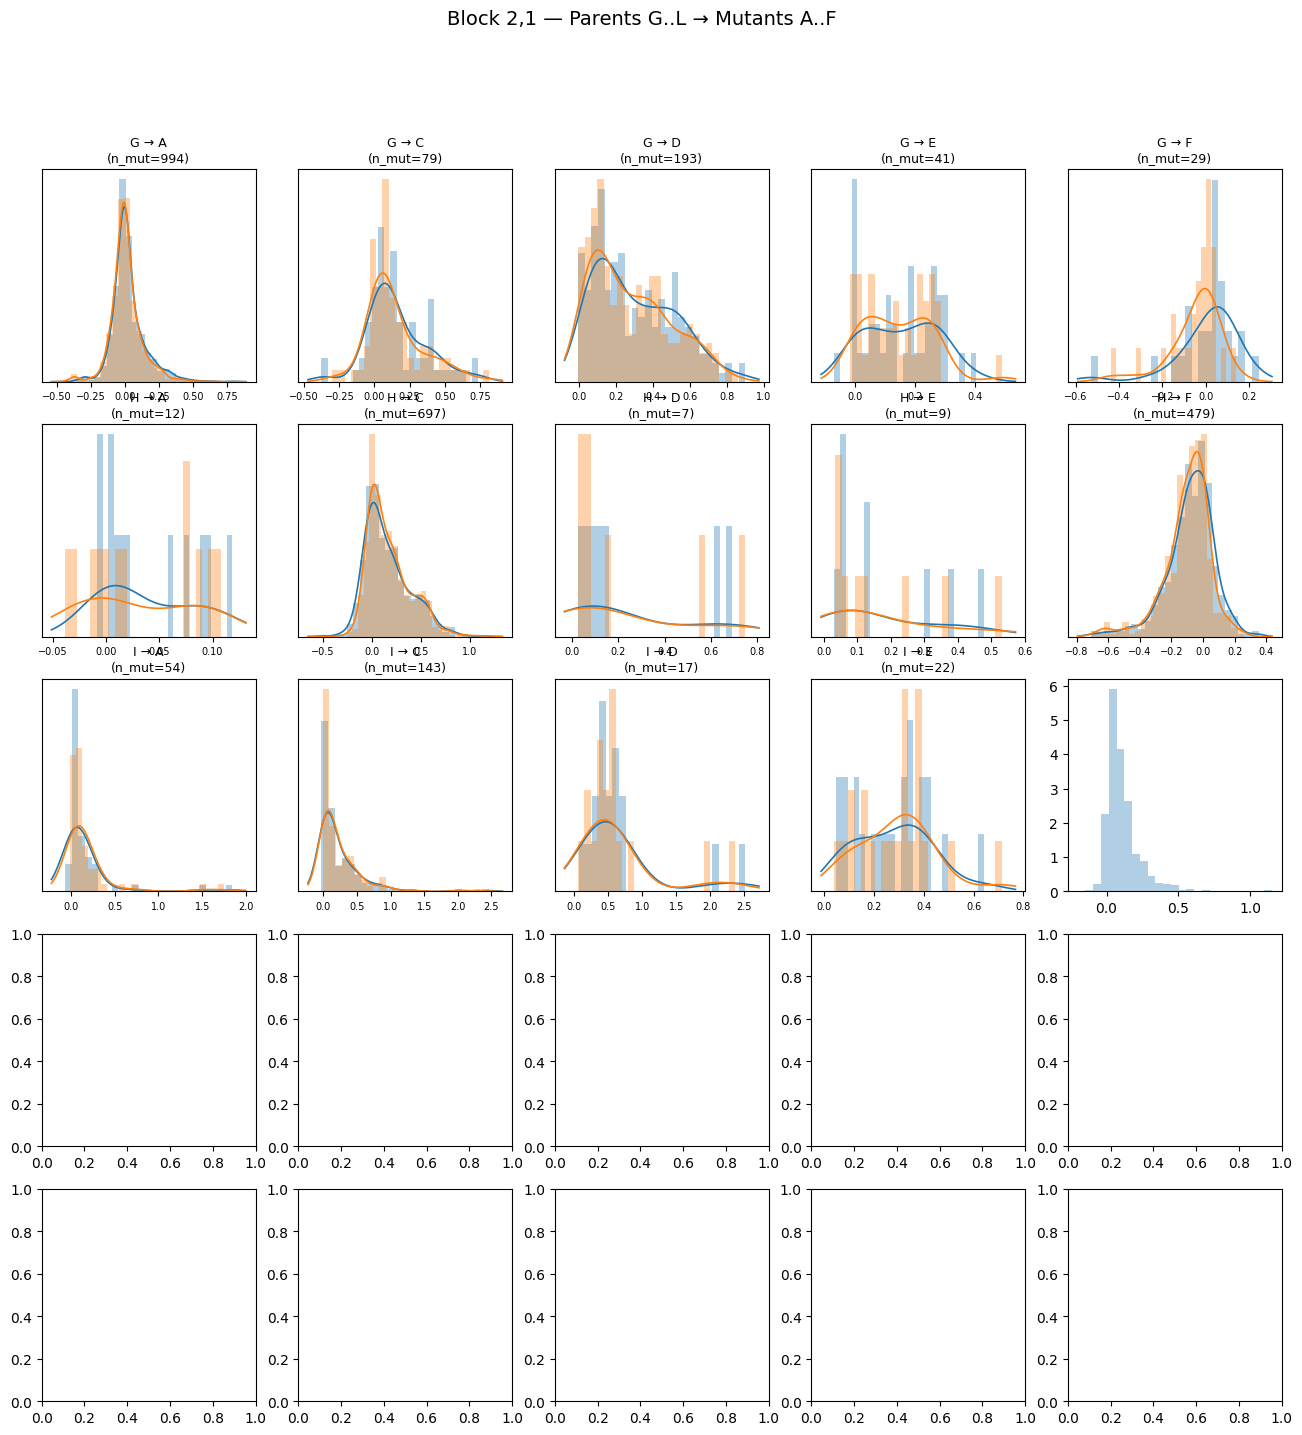

In [15]:

n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures
outdir = "aa_block_plots_position_7"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    # If there are NaNs, nanmean will handle them
    try:
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        # in case arr has fewer cols than expected, return empty
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        fig.suptitle(f"Block {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()
        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # if both are empty (shouldn't happen) mark
                if gn.size == 0 and gp.size == 0:
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(no valid group data)", ha='center', va='center', fontsize=9)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # hist plotting parameters
                bins = 25
                alpha = 0.35
                # hist (density=True so KDE overlay aligns)
                if gn.size > 0:
                    ax.hist(gn, bins=bins, density=True, alpha=alpha, label="Gram−" if ax_idx==0 else None)
                if gp.size > 0:
                    ax.hist(gp, bins=bins, density=True, alpha=alpha, label="Gram+" if ax_idx==0 else None)
                
                # KDE overlays (only if at least 2 unique points)
                try:
                    if gn.size >= 2 and np.nanstd(gn) > 0:
                        kde_gn = gaussian_kde(gn)
                    else:
                        kde_gn = None
                except Exception:
                    kde_gn = None
                try:
                    if gp.size >= 2 and np.nanstd(gp) > 0:
                        kde_gp = gaussian_kde(gp)
                    else:
                        kde_gp = None
                except Exception:
                    kde_gp = None
                
                # build x-range from combined non-nan values
                combined_vals = np.concatenate([x for x in [gn, gp] if x.size>0])
                if combined_vals.size > 0:
                    xmin, xmax = np.nanmin(combined_vals), np.nanmax(combined_vals)
                    # extend a bit for nicer KDE tails
                    pad = (xmax - xmin) * 0.08 if xmax > xmin else 0.5
                    xs = np.linspace(xmin - pad, xmax + pad, 200)
                else:
                    xs = np.linspace(-1, 1, 200)
                
                if kde_gn is not None:
                    ax.plot(xs, kde_gn(xs), lw=1.2, color='tab:blue')
                if kde_gp is not None:
                    ax.plot(xs, kde_gp(xs), lw=1.2, color='tab:orange')
                
                # subplot title: single mutation pair
                ax.set_title(f"{p_aa} → {m_aa}\n(n_mut={arr.shape[0]})", fontsize=9)
                ax.tick_params(axis="x", labelsize=7)
                ax.set_yticks([])
        
        # Add a single legend to the figure (outside the grid)
        handles = []
        labels = []
        handles.append(plt.Line2D([0], [0], color='tab:blue', lw=2))
        labels.append('Gram− KDE/hist')
        handles.append(plt.Line2D([0], [0], color='tab:orange', lw=2))
        labels.append('Gram+ KDE/hist')
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.93, 0.92), fontsize=10)
        
        plt.tight_layout(rect=[0, 0, 0.92, 0.96])
        
        outpath = os.path.join(outdir, f"aa_block_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Zakładamy, że ALL_AA, mutation_matrix, gram_neg, gram_pos są zdefiniowane ---

# Pomocnicza funkcja do wyliczania średnich
def compute_group_means(arr, gram_indices):
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    try:
        if any(idx >= arr.shape[1] for idx in gram_indices):
            return np.array([])
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        return np.array([])
    return means


# --- Główna analiza ---
pvals = []
pairs = []
nsizes = []  # przechowuje n

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
            continue

        gn = compute_group_means(arr, gram_neg)
        gp = compute_group_means(arr, gram_pos)

        if gn.size == 0 or gp.size == 0:
            continue

        # czyszczenie z NaN
        valid_mask = np.isfinite(gn) & np.isfinite(gp)
        gn_clean = gn[valid_mask]
        gp_clean = gp[valid_mask]

        # sprawdź, czy liczba próbek jest sensowna
        n = min(len(gn_clean), len(gp_clean))
        if n < 5:
            continue

        try:
            u_stat, p_val = mannwhitneyu(gn_clean, gp_clean, alternative='two-sided', method='auto')
        except Exception:
            continue

        pvals.append(p_val)
        pairs.append((p_aa, m_aa, gn_clean, gp_clean))
        nsizes.append(n)

# --- FILTR: tylko pary z p < 0.01 ---
sig_idx = [i for i, p in enumerate(pvals) if p < 0.01]

if not sig_idx:
    raise ValueError("Brak par z p < 0.01 — nic do pokazania.")

sig_pairs = [pairs[i] for i in sig_idx]
sig_pvals = [pvals[i] for i in sig_idx]
sig_nsizes = [nsizes[i] for i in sig_idx]

# --- Sortowanie po p-value ---
sorted_idx = np.argsort(sig_pvals)
sig_pairs = [sig_pairs[i] for i in sorted_idx]
sig_pvals = [sig_pvals[i] for i in sorted_idx]
sig_nsizes = [sig_nsizes[i] for i in sorted_idx]

print(f"\n✅ Znaleziono {len(sig_pairs)} par z p < 0.01.")
for i, (p_aa, m_aa, _, _) in enumerate(sig_pairs[:10]):
    print(f"{i+1:2d}. {p_aa} → {m_aa}   p = {sig_pvals[i]:.3e}   (n={sig_nsizes[i]})")

# --- Tworzenie wykresów po 25 ---
outdir = "dbs_mannwhitney"
os.makedirs(outdir, exist_ok=True)

chunks = [sig_pairs[i:i+25] for i in range(0, len(sig_pairs), 25)]
p_chunks = [sig_pvals[i:i+25] for i in range(0, len(sig_pvals), 25)]
n_chunks = [sig_nsizes[i:i+25] for i in range(0, len(sig_nsizes), 25)]

for block_num, (pair_block, pval_block, n_block) in enumerate(zip(chunks, p_chunks, n_chunks), start=1):

    fig, axes = plt.subplots(5, 5, figsize=(16, 16))
    axes_flat = axes.flatten()
    fig.suptitle(f"Mann–Whitney U test (p < 0.01)\nBlock {block_num} — {len(pair_block)} pairs", fontsize=14)

    # ustalenie zakresu osi na podstawie wszystkich danych z bloku
    all_vals = np.concatenate([np.concatenate([gn, gp]) for _, _, gn, gp in pair_block])
    limit_min, limit_max = np.percentile(all_vals, [1, 99])
    limit_min = - 0.1
    limit_max = 0.1
    pad = (limit_max - limit_min) * 0.1
    limit_min -= pad
    limit_max += pad

    for ax, (p_aa, m_aa, gn, gp), pval, n in zip(axes_flat, pair_block, pval_block, n_block):
        valid_mask = np.isfinite(gn) & np.isfinite(gp)
        gn_valid = gn[valid_mask]
        gp_valid = gp[valid_mask]

        # Scatter
        ax.scatter(gn_valid, gp_valid, s=15, alpha=0.6, color='tab:green', edgecolors='none')
        ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)

        # Linie referencyjne: y=x, x=0, y=0
        ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)  # y=x
        ax.axhline(0, color='gray', linestyle=':', lw=0.8)  # y=0
        ax.axvline(0, color='gray', linestyle=':', lw=0.8)  # x=0

        ax.set_xlim(limit_min, limit_max)
        ax.set_ylim(limit_min, limit_max)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlim(limit_min, limit_max)
        ax.set_ylim(limit_min, limit_max)
        ax.set_aspect('equal', adjustable='box')

        # Gwiazdki istotności
        if pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = "ns"

        # Tytuł subplotu: para, p-value, n
        ax.set_title(f"{p_aa}→{m_aa}\np={pval:.1e} {star}\nn={n}", fontsize=8)
        ax.tick_params(axis='both', labelsize=7)

    # Wyłączenie pustych osi (jeśli mniej niż 25)
    for ax in axes_flat[len(pair_block):]:
        ax.axis("off")

    fig.text(0.5, 0.04, "Gram− Mean", ha="center", fontsize=12)
    fig.text(0.04, 0.5, "Gram+ Mean", va="center", rotation="vertical", fontsize=12)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

    outpath = os.path.join(outdir, f"dbs_mannwhitney_block_{block_num}.png")
    plt.savefig(outpath, dpi=300)
    plt.close(fig)
    print(f"💾 Saved: {outpath}")

print(f"\n✅ Utworzono {len(chunks)} wykresów (po 25 par każdy) w folderze: {outdir}")



✅ Znaleziono 43 par z p < 0.01.
 1. L → N   p = 8.010e-16   (n=3379)
 2. P → F   p = 2.167e-11   (n=1748)
 3. F → R   p = 1.767e-10   (n=226)
 4. F → I   p = 8.535e-10   (n=1159)
 5. F → Y   p = 4.562e-09   (n=1711)
 6. I → F   p = 7.993e-09   (n=1724)
 7. I → N   p = 3.030e-08   (n=1004)
 8. G → M   p = 3.345e-08   (n=499)
 9. A → M   p = 2.091e-07   (n=893)
10. A → S   p = 4.883e-07   (n=1133)
💾 Saved: dbs_mannwhitney/dbs_mannwhitney_block_1.png
💾 Saved: dbs_mannwhitney/dbs_mannwhitney_block_2.png

✅ Utworzono 2 wykresów (po 25 par każdy) w folderze: dbs_mannwhitney


In [46]:
from scipy.stats import shapiro
import numpy as np

passes_pos = 0
fails_pos = 0
passes_neg = 0
fails_neg = 0
tested_pos = 0
tested_neg = 0

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        # Gram-negative test
        if isinstance(gn, np.ndarray) and gn.size >= 3:  # Shapiro requires n>=3
            tested_neg += 1
            stat, pval = shapiro(gn)
            if pval >= 0.01:
                passes_neg += 1
            else:
                fails_neg += 1
        # Gram-positive test
        if isinstance(gp, np.ndarray) and gp.size >= 3:
            tested_pos += 1
            stat, pval = shapiro(gp)
            if pval >= 0.05:
                passes_pos += 1
            else:
                fails_pos += 1

print("📊 Shapiro–Wilk Normality Test Results:")
print(f"Gram−  →  passed: {passes_neg} / {tested_neg}  ({passes_neg/tested_neg:.1%})")
print(f"Gram+  →  passed: {passes_pos} / {tested_pos}  ({passes_pos/tested_pos:.1%})")


📊 Shapiro–Wilk Normality Test Results:
Gram−  →  passed: 127 / 356  (35.7%)
Gram+  →  passed: 95 / 356  (26.7%)


In [47]:
from scipy.stats import shapiro, skew, kurtosis, gaussian_kde
import numpy as np

# Optional: dip test for multimodality (requires package 'diptest')
try:
    from diptest import diptest
    has_diptest = True
except ImportError:
    has_diptest = False
    print("⚠️ diptest not installed, using kurtosis heuristic for bimodality")

results = []

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        for label, arr in [("Gram−", gn), ("Gram+", gp)]:
            if isinstance(arr, np.ndarray) and arr.size >= 3:
                arr = arr[np.isfinite(arr)]
                if len(arr) < 3:
                    continue

                # --- 1. Shapiro–Wilk normality test ---
                try:
                    stat, p_norm = shapiro(arr)
                except Exception:
                    p_norm = np.nan

                # --- 2. Bimodality detection ---
                if has_diptest:
                    try:
                        dip, p_dip = diptest(arr)
                    except Exception:
                        p_dip = np.nan
                else:
                    # Heuristic: high kurtosis (>3) and skew near 0 → possibly bimodal
                    k = kurtosis(arr, fisher=False)
                    p_dip = 1.0 if (k < 2.5 or k > 4.5) else 0.01

                # --- 3. Skewness & kurtosis ---
                sk = skew(arr)
                k = kurtosis(arr, fisher=False)

                results.append({
                    "pair": f"{p_aa}->{m_aa}",
                    "group": label,
                    "n": len(arr),
                    "p_normal": p_norm,
                    "p_bimodal": p_dip,
                    "skew": sk,
                    "kurtosis": k
                })

results_df = pd.DataFrame(results)

# --- Summary statistics ---
normal_pass = (results_df["p_normal"] >= 0.01).sum()
normal_fail = (results_df["p_normal"] < 0.01).sum()

bimodal_pass = (results_df["p_bimodal"] < 0.01).sum()  # likely bimodal
skewed = (np.abs(results_df["skew"]) > 1).sum()
heavy_tailed = (results_df["kurtosis"] > 4).sum()

print("📊 Distribution Shape Summary")
print(f"Normal-like distributions (p≥0.01): {normal_pass}/{len(results_df)}")
print(f"Non-normal distributions (p<0.01): {normal_fail}/{len(results_df)}")
print(f"Likely bimodal (Dip/kurtosis): {bimodal_pass}/{len(results_df)}")
print(f"Strongly skewed (|skew|>1): {skewed}/{len(results_df)}")
print(f"Heavy-tailed (kurtosis>4): {heavy_tailed}/{len(results_df)}")

# Optional: view the worst offenders
print("\n🔍 Most bimodal examples:")
print(results_df.sort_values("p_bimodal").head(10)[["pair", "group", "p_bimodal", "skew", "kurtosis"]])


⚠️ diptest not installed, using kurtosis heuristic for bimodality
📊 Distribution Shape Summary
Normal-like distributions (p≥0.01): 254/712
Non-normal distributions (p<0.01): 458/712
Likely bimodal (Dip/kurtosis): 0/712
Strongly skewed (|skew|>1): 495/712
Heavy-tailed (kurtosis>4): 428/712

🔍 Most bimodal examples:
     pair  group  p_bimodal      skew  kurtosis
0    A->C  Gram−       0.01  1.470086  3.210693
566  S->R  Gram−       0.01  1.035876  3.332392
561  S->N  Gram+       0.01 -1.074470  2.623891
198  G->P  Gram−       0.01  0.757338  2.840084
559  S->M  Gram+       0.01  0.796229  2.868950
404  N->H  Gram−       0.01  0.587569  2.572744
202  G->R  Gram−       0.01 -1.121429  3.513234
555  S->K  Gram+       0.01 -1.154469  3.042111
554  S->K  Gram−       0.01 -1.131830  3.063804
553  S->I  Gram+       0.01 -1.054561  2.766145


In [19]:
def create_square_plot(
    data: np.ndarray,
    classification: str | None = None,
    cmap: str = "coolwarm",
    title: str | None = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: bool | None = None,
    ax: plt.Axes | None = None,   # ✅ Optional axis
    vmin: float | None = None,    # ✅ New
    vmax: float | None = None,    # ✅ New
):
    """
    Create a sorted amino acid × amino acid heatmap based on a chosen classification.

    If `ax` is provided, the plot will be drawn on that axis instead of creating a new figure.
    """
    data = np.asarray(data, dtype=float)
    n = data.shape[0]
    if data.shape[0] != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    df = pd.DataFrame(data, index=aas, columns=aas)

    # Create figure/axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = plt.gcf()

    # === Case 1: no classification ===
    if classification is None:
        sns.heatmap(df, cmap=cmap, square=True, cbar=True, ax=ax,
                    vmin=vmin, vmax=vmax)
        if not title:
            title = "Amino acid × amino acid (unsorted)"
        ax.set_title(title, fontsize=14)
        # ax.set_xlabel("Amino acid")
        # ax.set_ylabel("Amino acid")
        plt.tight_layout()
        if return_fig:
            return fig, ax
        else:
            return None

    # === Case 2: classification selected ===
    if classification not in AMINO_ACID_CLASSES:
        raise ValueError(f"Unknown classification: {classification}")

    groups = AMINO_ACID_CLASSES[classification]
    sorted_groups = list(groups.keys())

    sorted_aas = [aa for group in sorted_groups for aa in aas if aa in groups[group]]
    missing = [aa for aa in aas if aa not in sorted_aas]
    sorted_aas.extend(missing)

    df_sorted = df.loc[sorted_aas, sorted_aas]

    # ✅ Apply vmin/vmax if provided
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax,
                vmin=vmin, vmax=vmax)

    if not title:
        title = f" Mutational signatures ({classification} classification)"
    ax.set_title(title, fontsize=14)
    # ax.set_xlabel("Amino acid")
    # ax.set_ylabel("Amino acid")

    # === Group boundaries and labels ===
    group_sizes = [len(groups[g]) for g in sorted_groups if any(aa in aas for aa in groups[g])]
    boundaries = np.cumsum(group_sizes)

    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=1)
        ax.axvline(b, color="black", lw=1)

    if show_labels:
        midpoints = np.array(boundaries) - np.array(group_sizes) / 2
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(-1.5, mid, g, va="center", ha="right", fontsize=10)
        ylim = ax.get_ylim()
        xlim = ax.get_xlim()
        offset = len(aas) * 0.05
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(mid, len(aas) + offset, g, va="top", ha="center", fontsize=10)
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)

    plt.tight_layout()
    if return_fig:
        return fig, ax
    else:
        return None


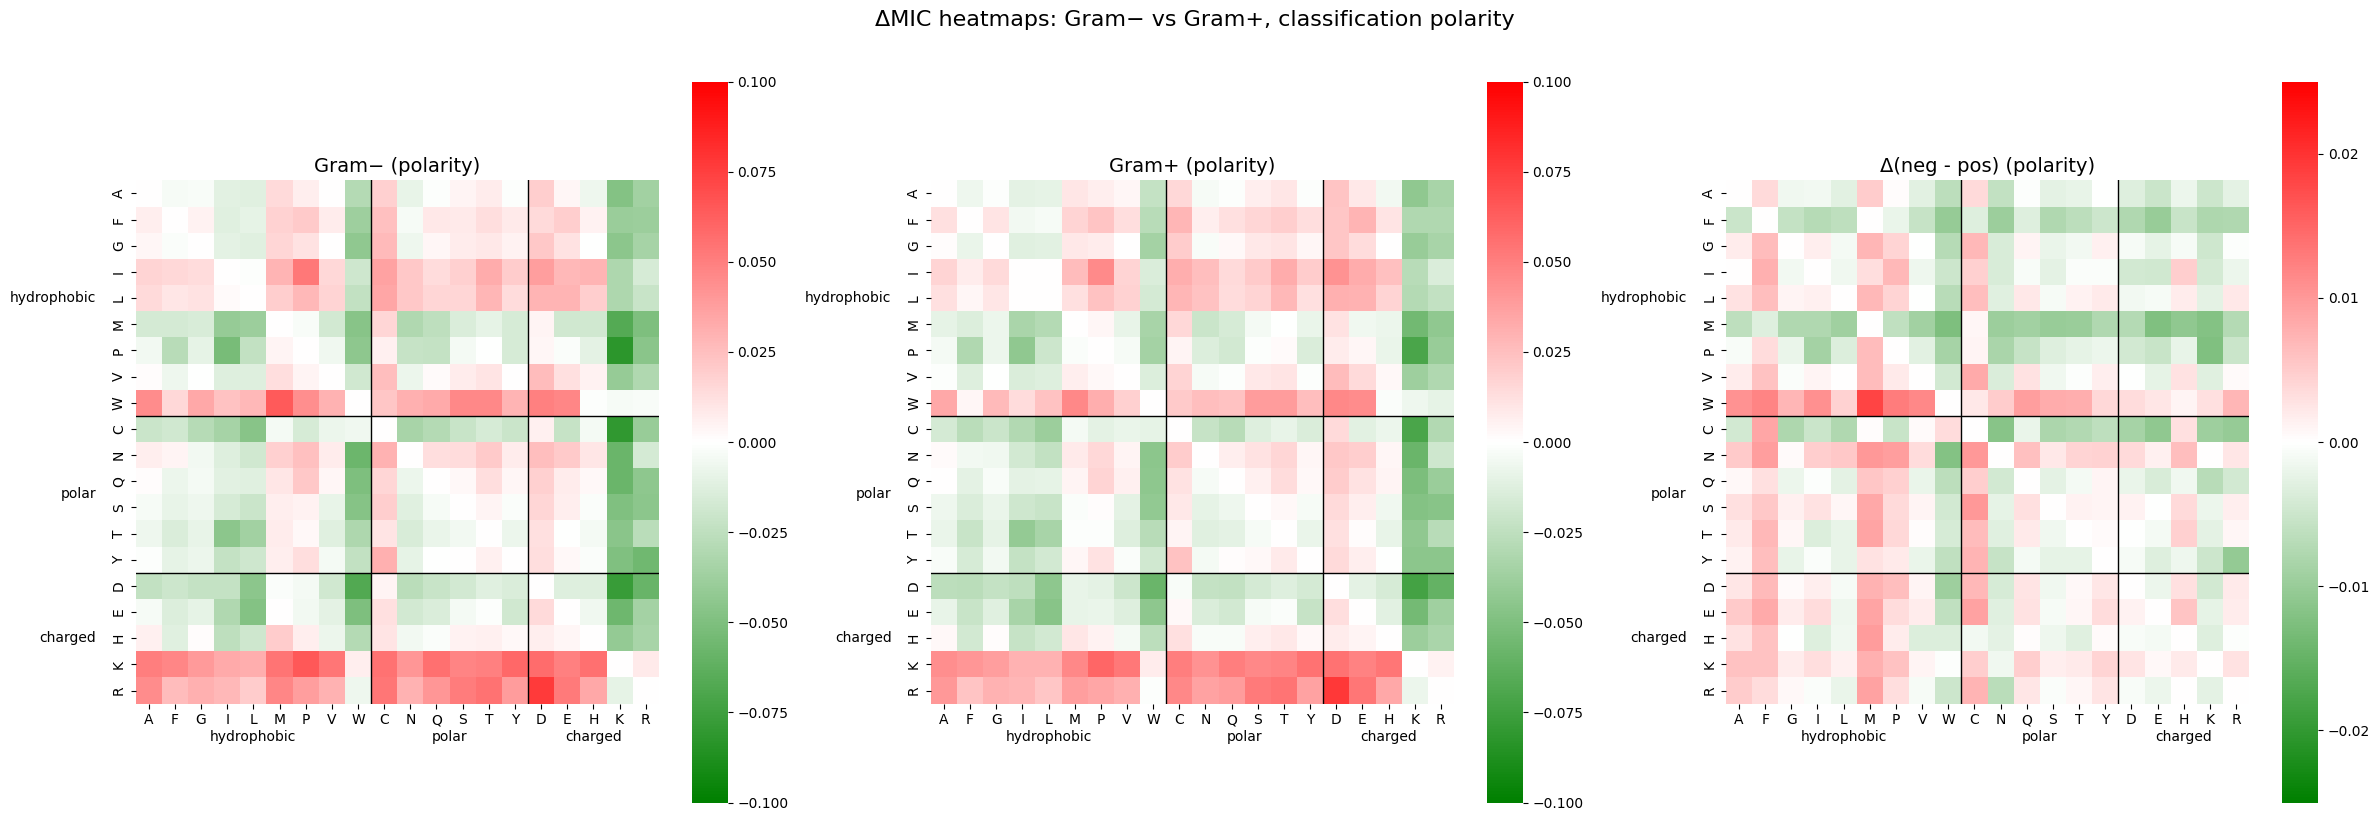

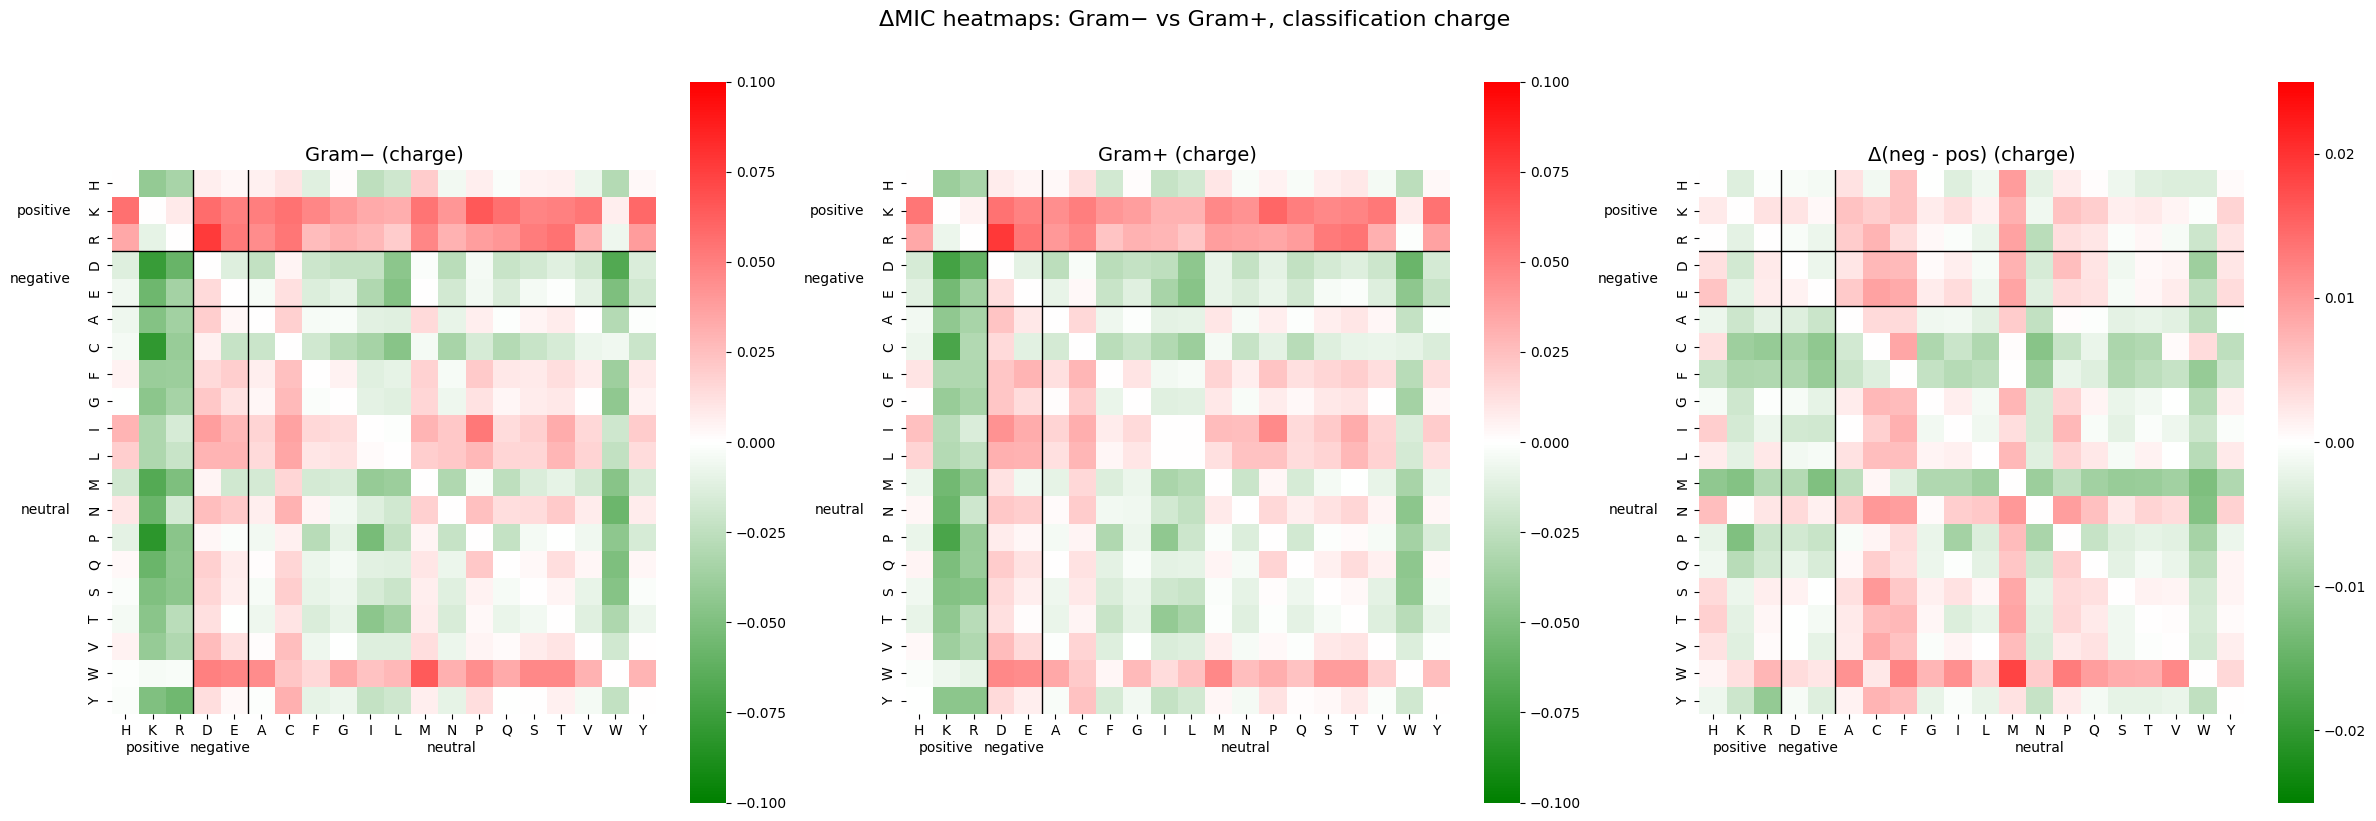

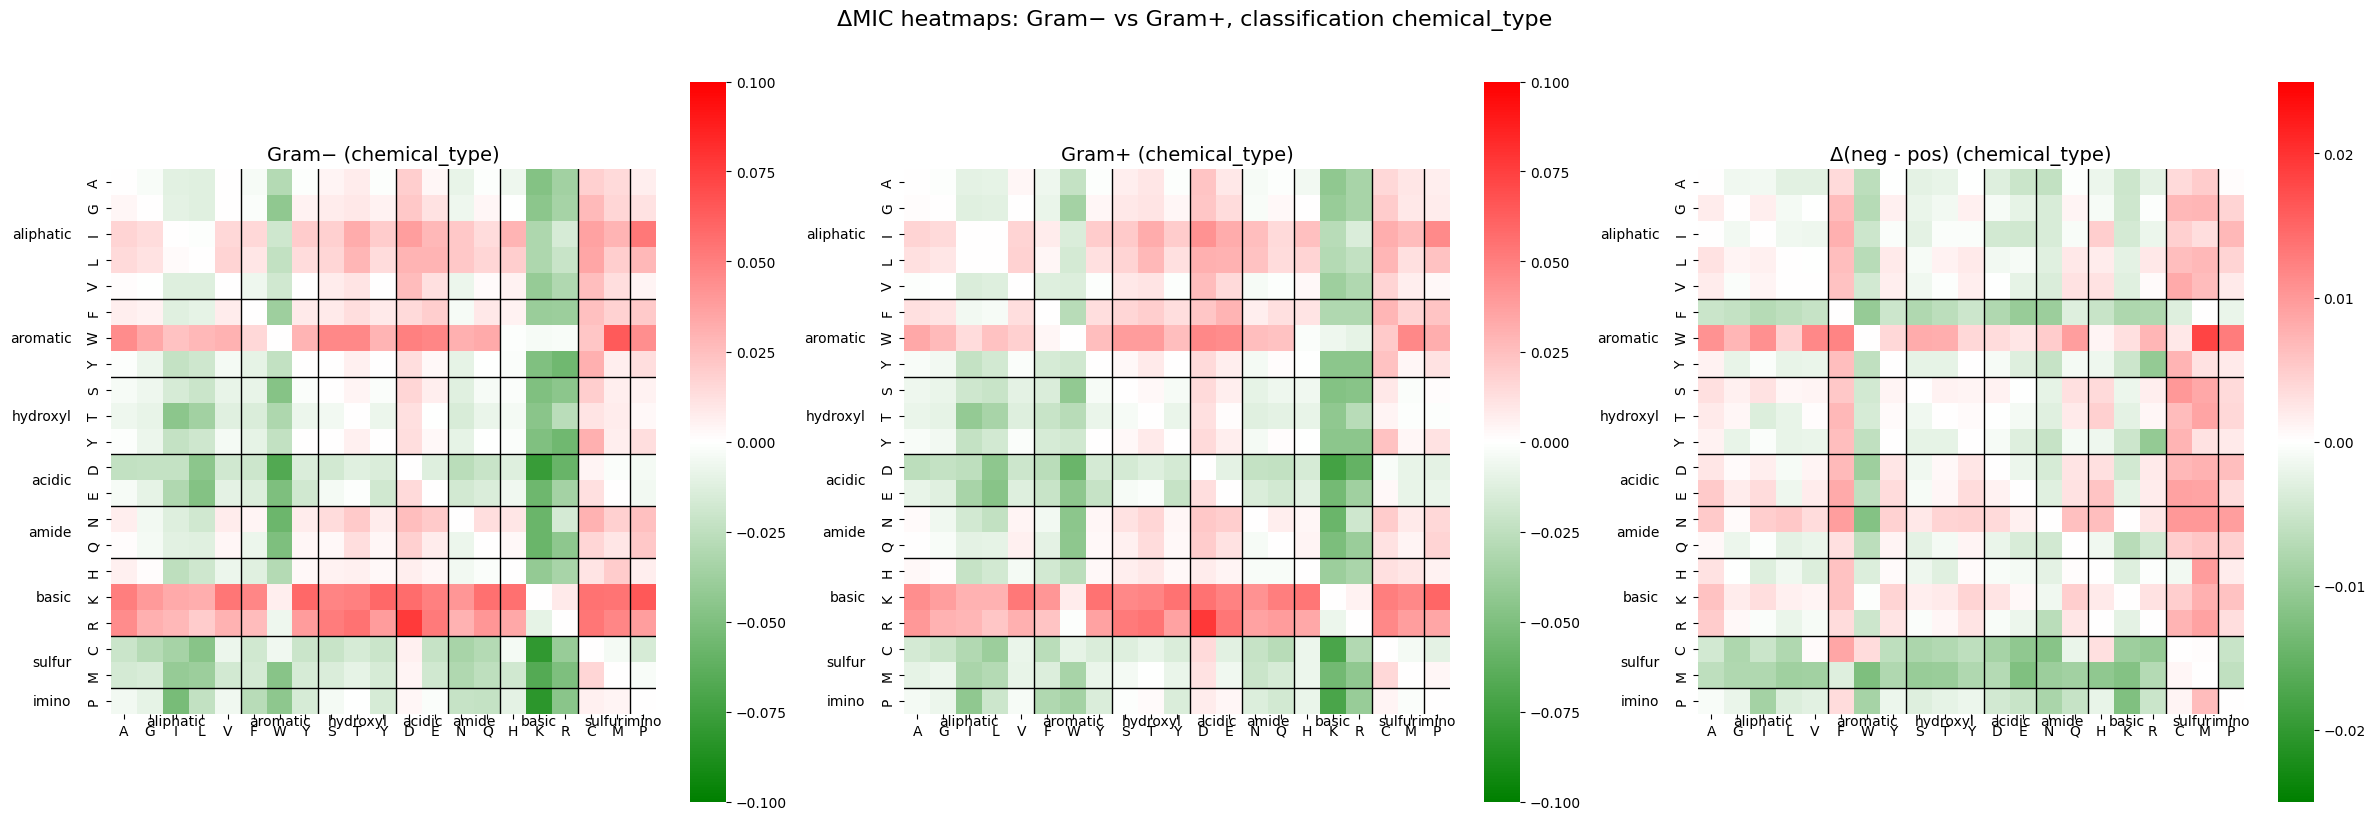

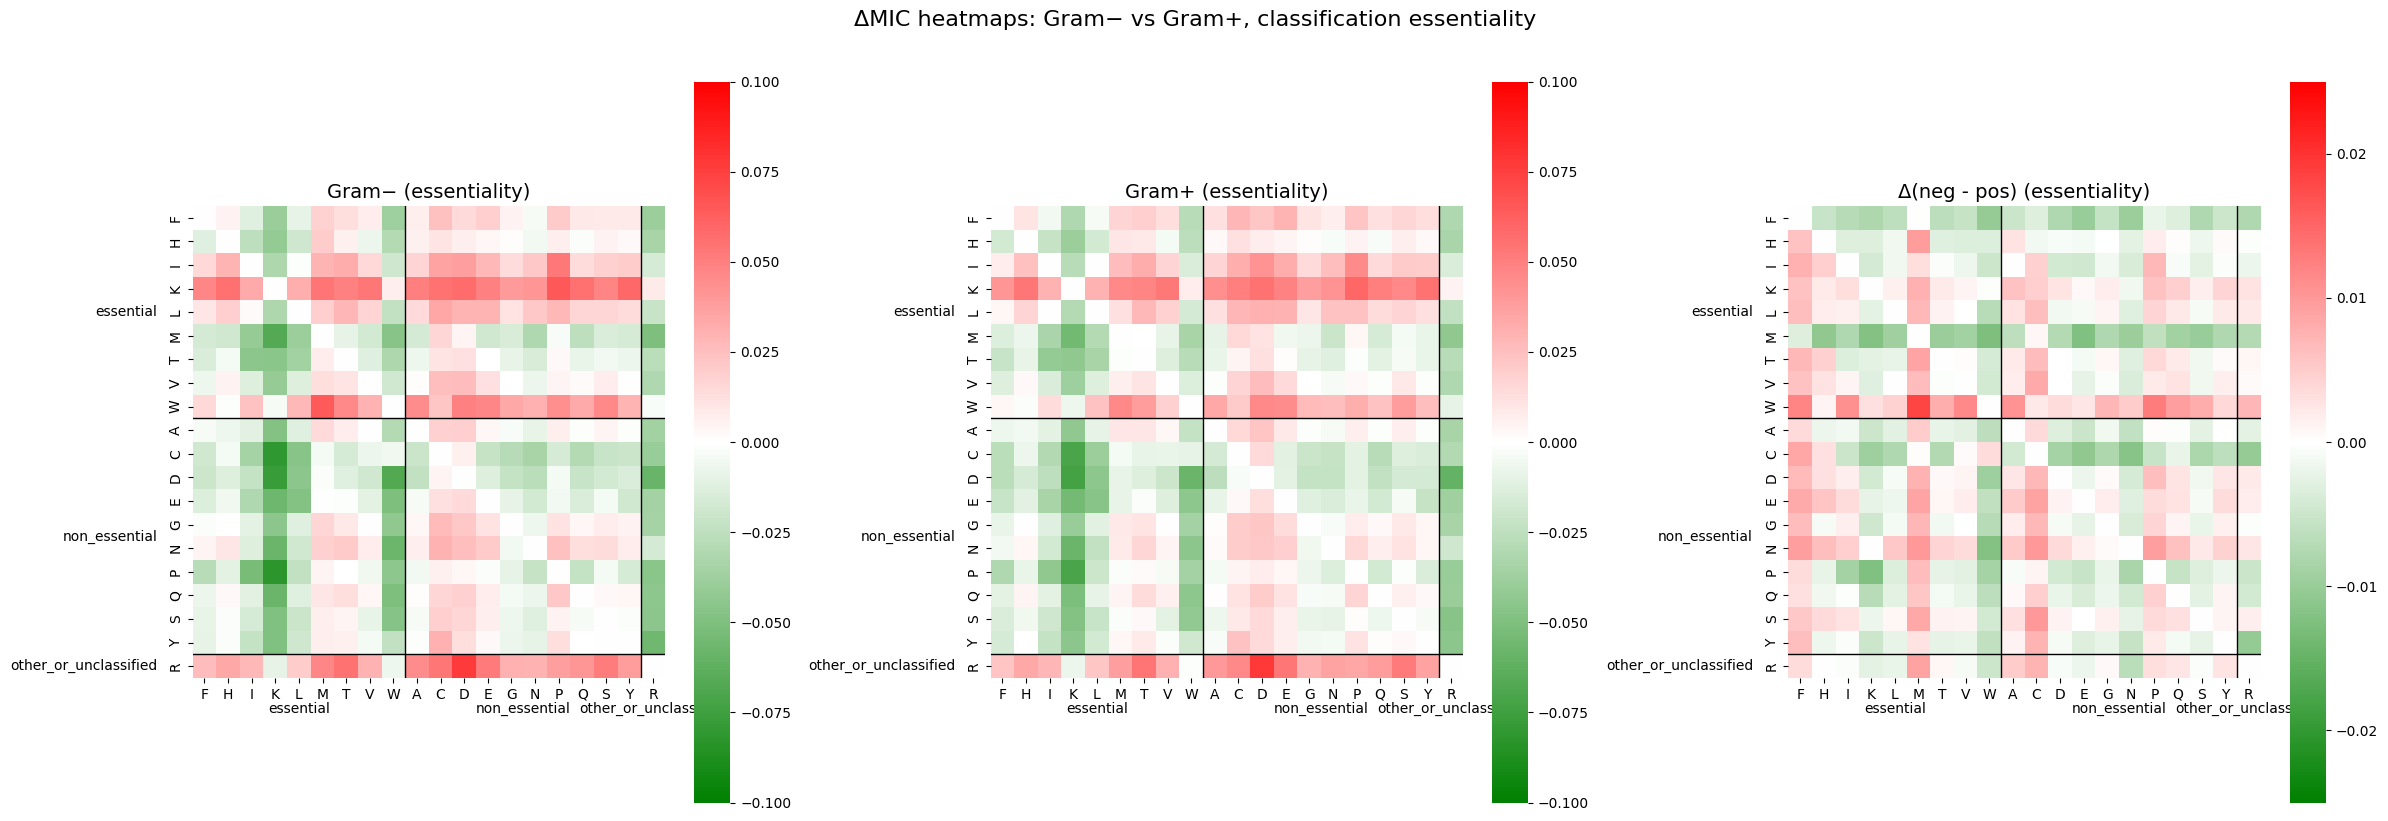

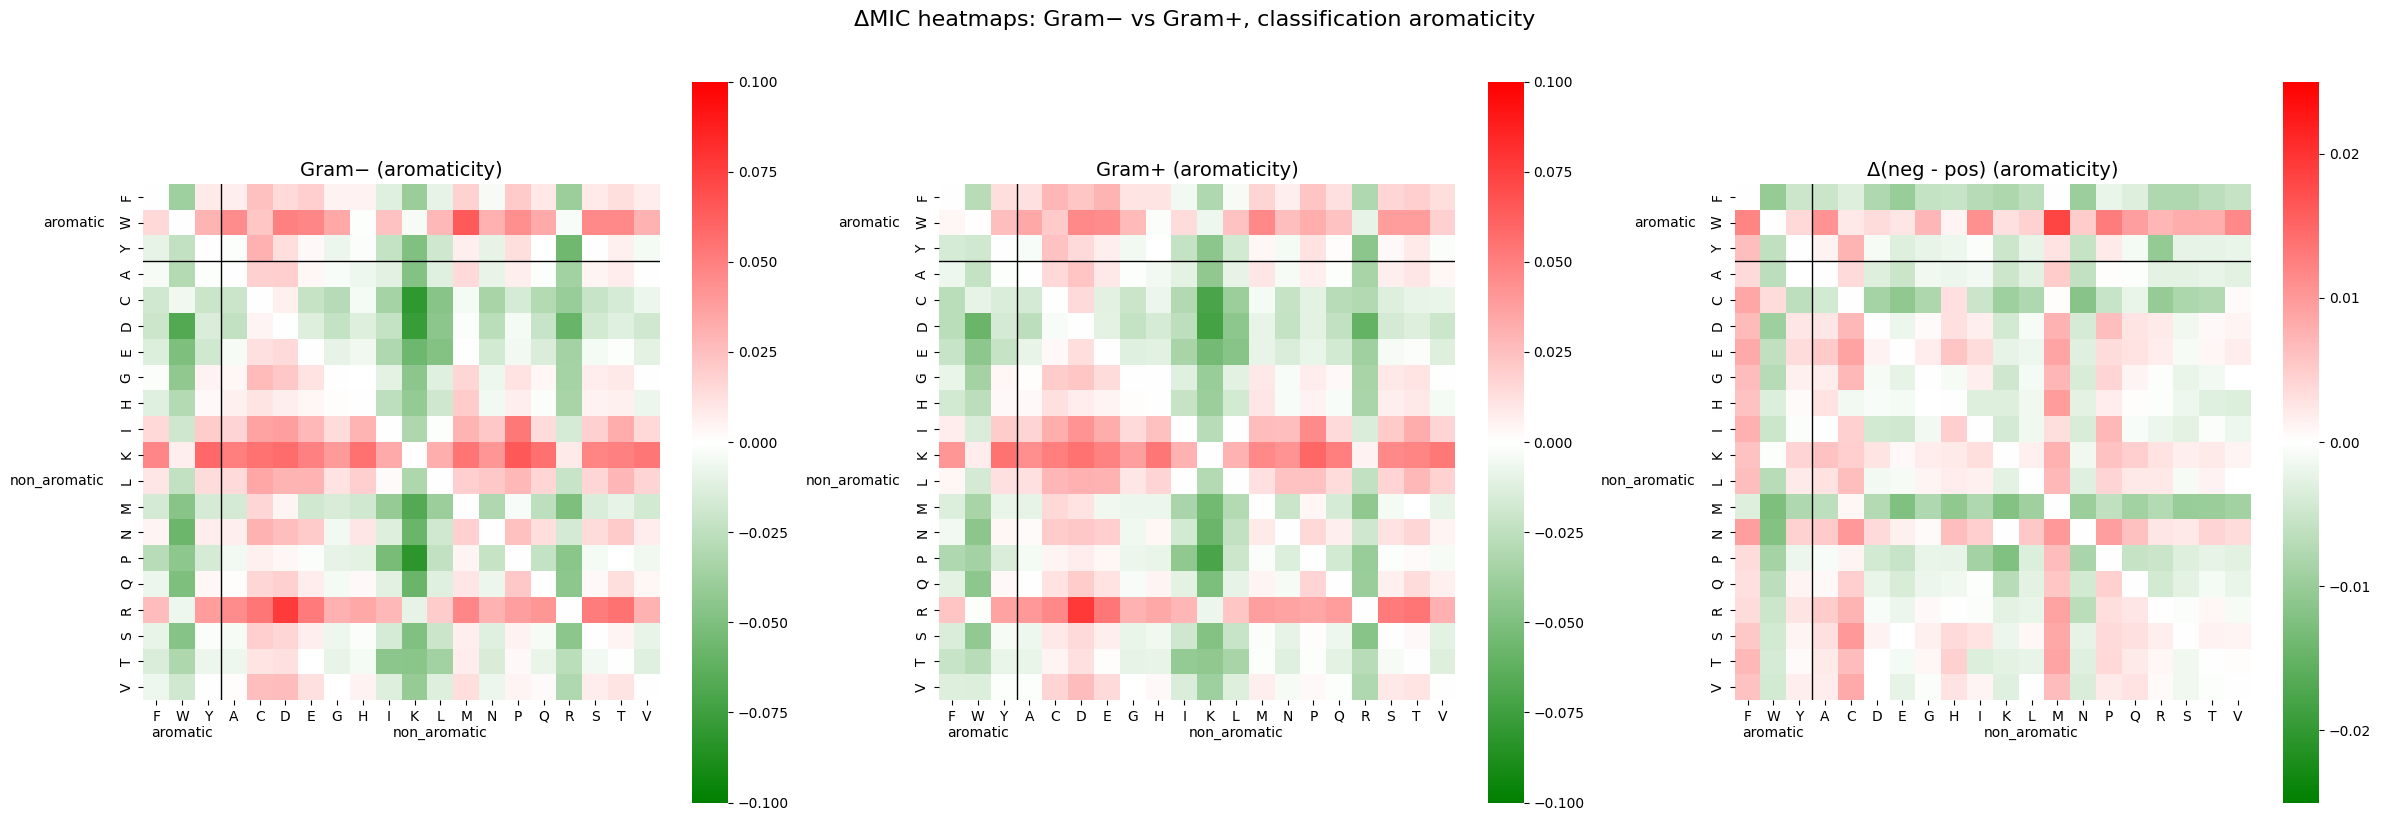

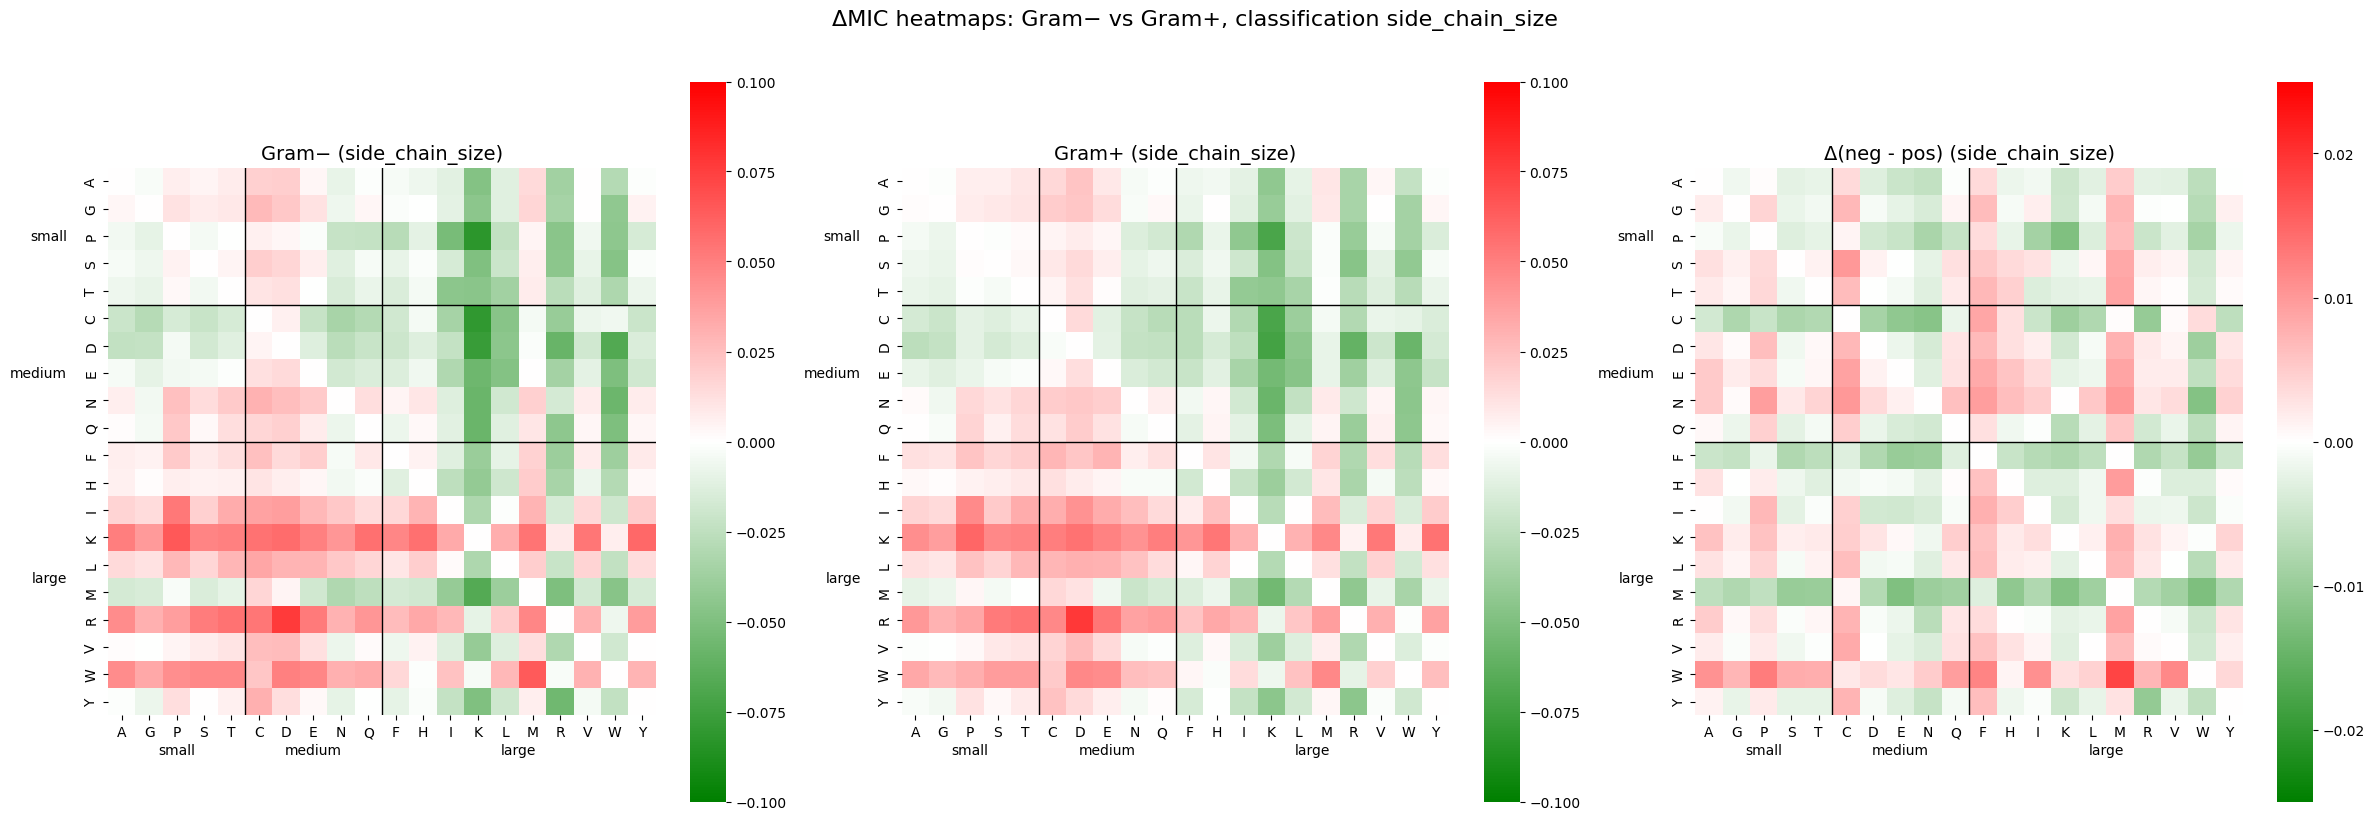

In [11]:
colors = [(0, "green"), (0.5, "white"), (1, "red")]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("greenwarm", colors)


for c in classes:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

    # Draw on given axes instead of creating new ones
    create_square_plot(
        mean_gram_neg_matrix.astype(float),
        classification=c,
        title=f"Gram− ({c})",
        ax=ax1,
        show_labels=True,
        return_fig=False,
        vmin = -0.1,
        vmax = 0.1,
        cmap=custom_cmap

    )

    create_square_plot(
        mean_gram_pos_matrix.astype(float),
        classification=c,
        title=f"Gram+ ({c})",
        ax=ax2,
        show_labels=True,
        return_fig=False,
        vmin = -0.1,
        vmax = 0.1,
        cmap=custom_cmap
    )
    
    difference_matrix = mean_gram_neg_matrix - mean_gram_pos_matrix

    create_square_plot(
        difference_matrix.astype(float),
        classification=c,
        title=f"Δ(neg - pos) ({c})",
        ax=ax3,
        show_labels=True,
        return_fig=False,
        vmin=-0.025,
        vmax=0.025,
        cmap=custom_cmap
    )

    fig.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


TOP LAST 7

In [21]:



def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

mic_bac_columns = parents.head().columns.tolist()[2:]

diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="Name",
    match_col_mutants="parent_name",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

#possition mask (take only mutations on first/last 7 positions)0

position_mask = (
    (diff_clean["position"] < 7) |
    (diff_clean["position"] >= diff_clean["parent"].str.len() - 7)
    )
diff_clean = diff_clean[position_mask]



delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


# Prepare empty mean matrix

mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

gram_neg = [0,1,2,3,4,5,6,11,12,13,16,17,18,19,20,22,23,24,29,30,31,32]
gram_pos = [7,8,9,10,14,15,21,25,26,27,28,33]

##having mutation_matrix, make histogram plot of mean values for gram_pos and gram_neg for each entry of mutation matrix
gram_means = pd.DataFrame(index=ALL_AA, columns=ALL_AA, dtype=object)
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim == 2:
            # mean over bacteria within each group → one value per mutation
            gram_neg_means = np.nanmean(arr[:, gram_neg], axis=1)
            gram_pos_means = np.nanmean(arr[:, gram_pos], axis=1)
            gram_means.at[p_aa, m_aa] = (gram_neg_means, gram_pos_means)
        else:
            gram_means.at[p_aa, m_aa] = ([], [])


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan


# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)



AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



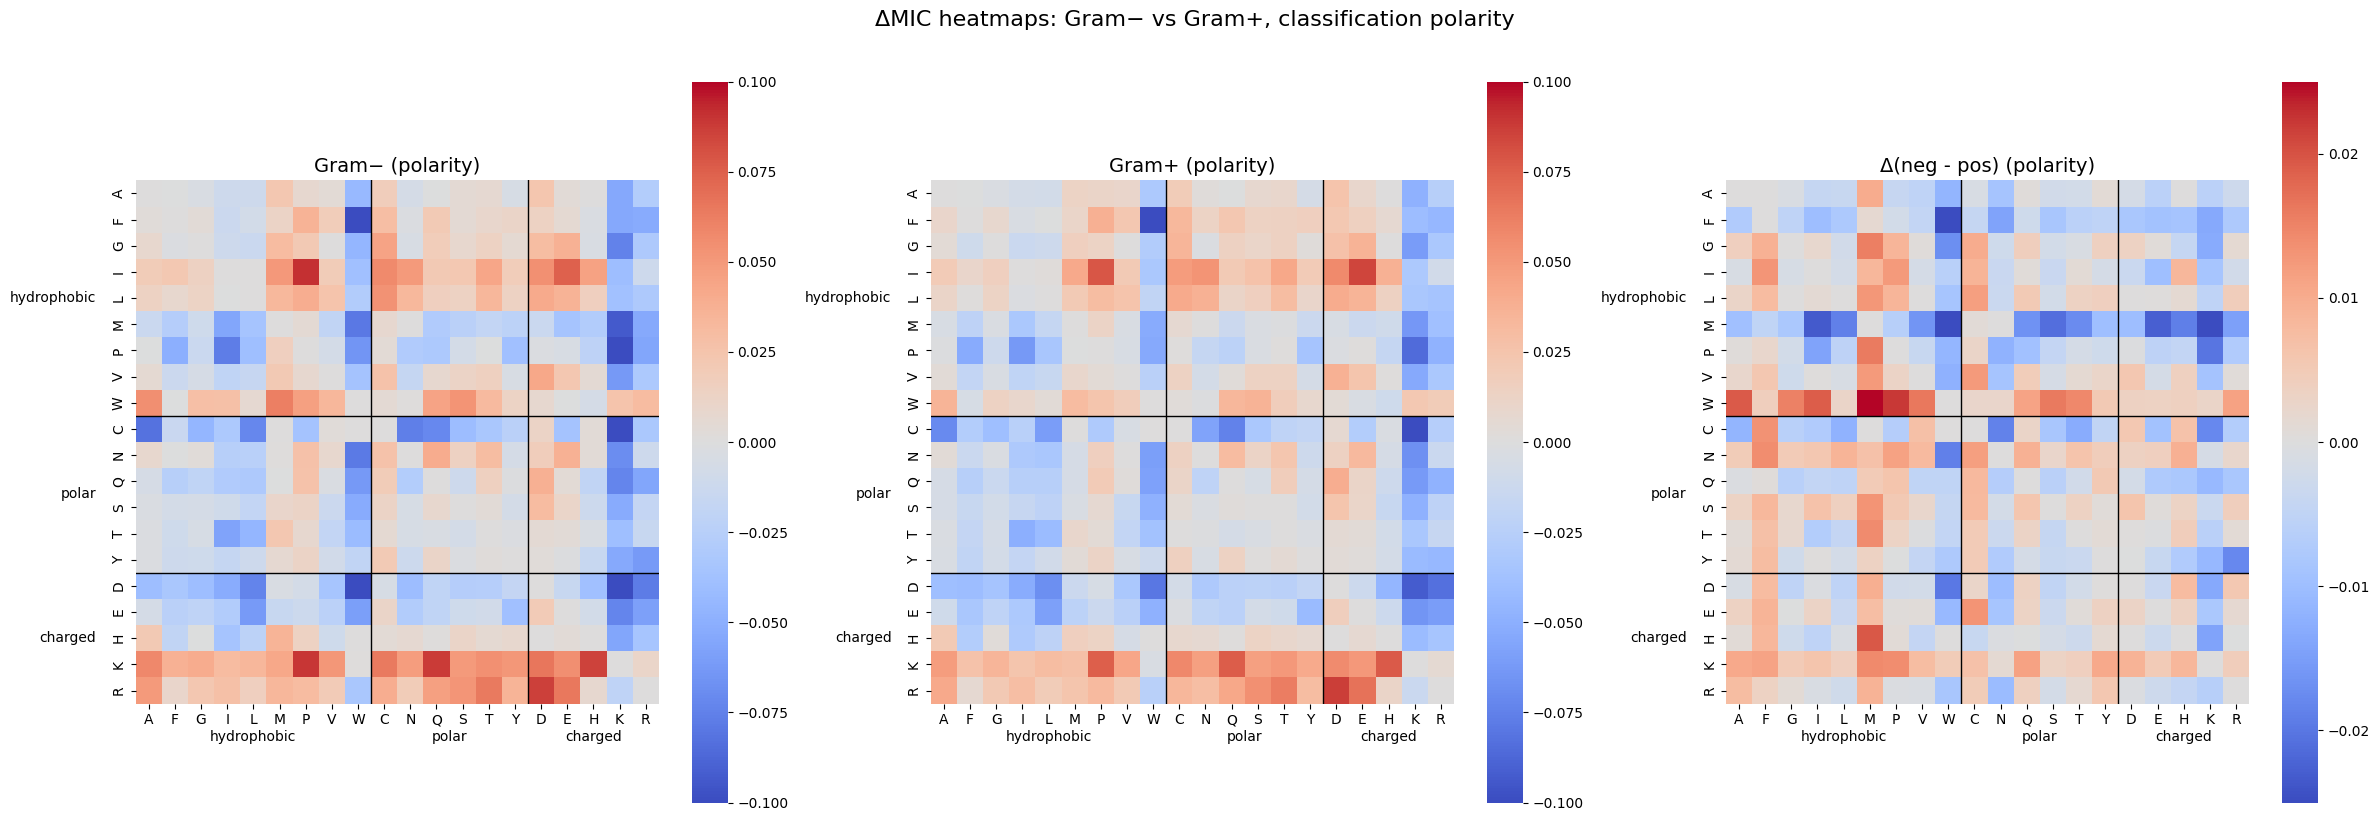

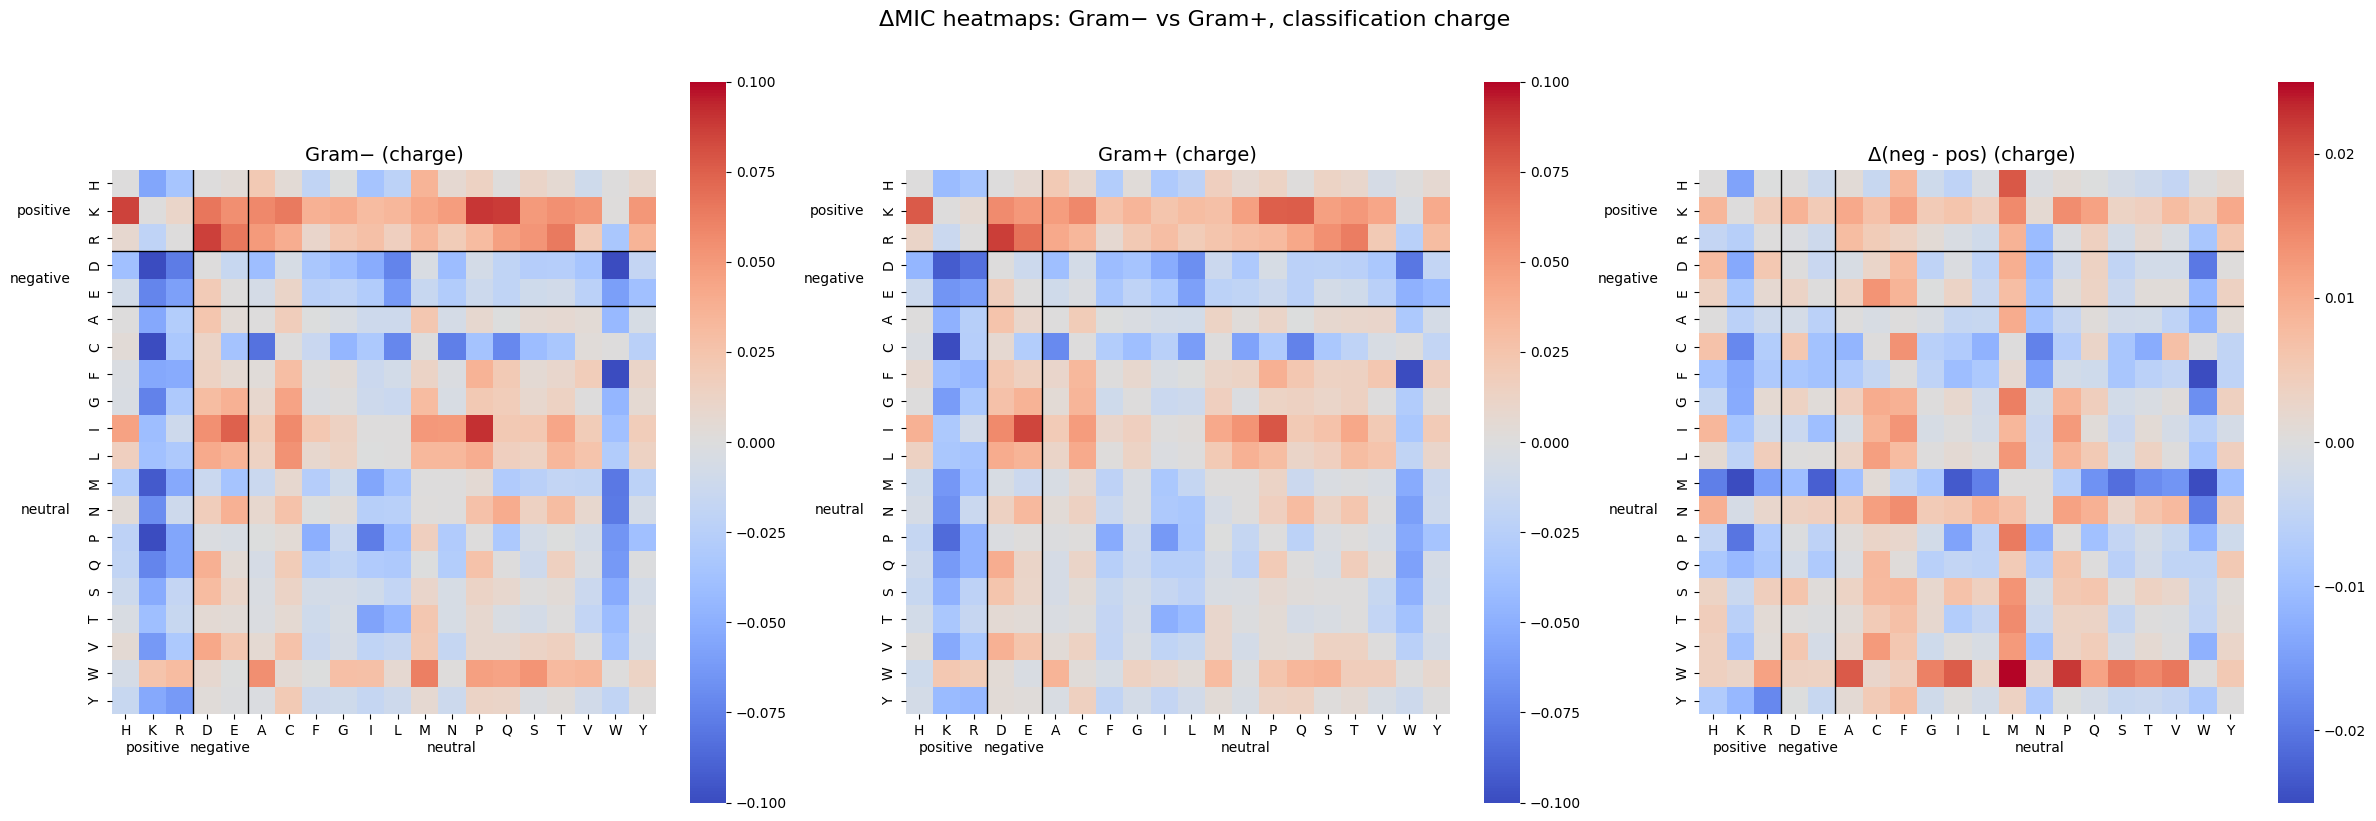

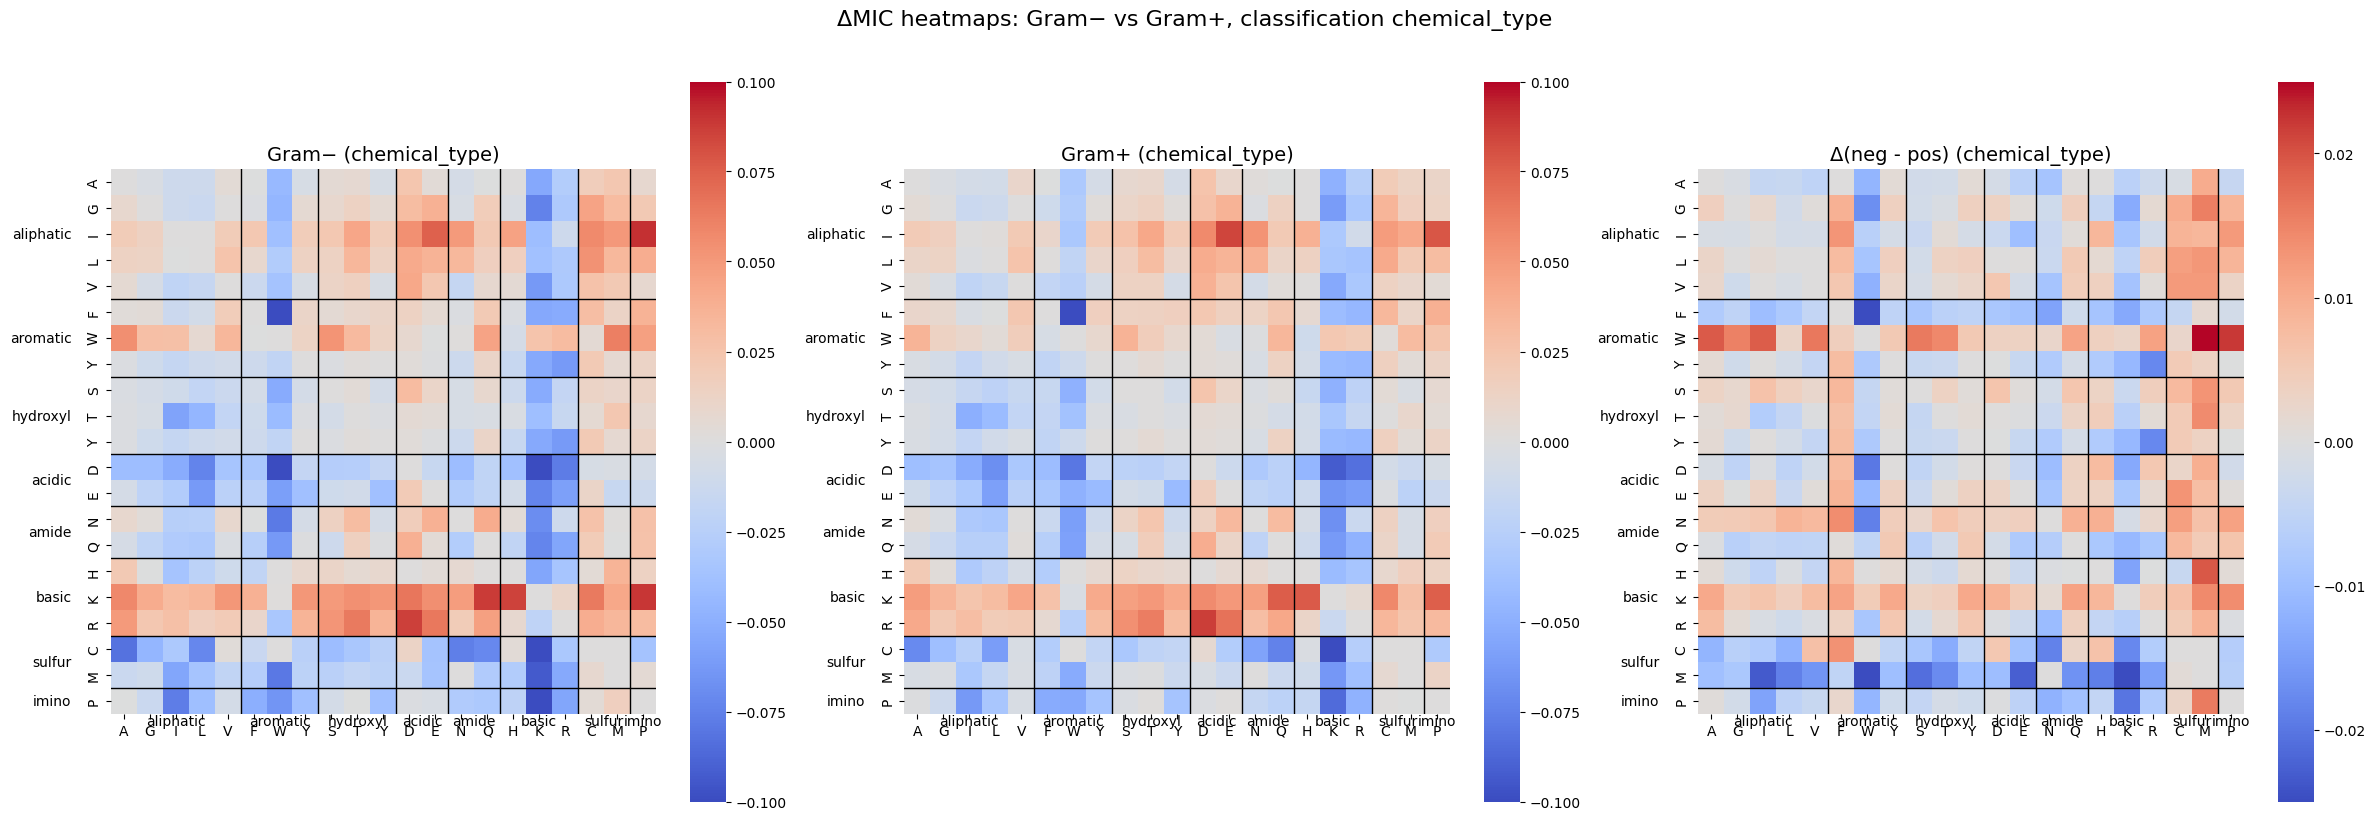

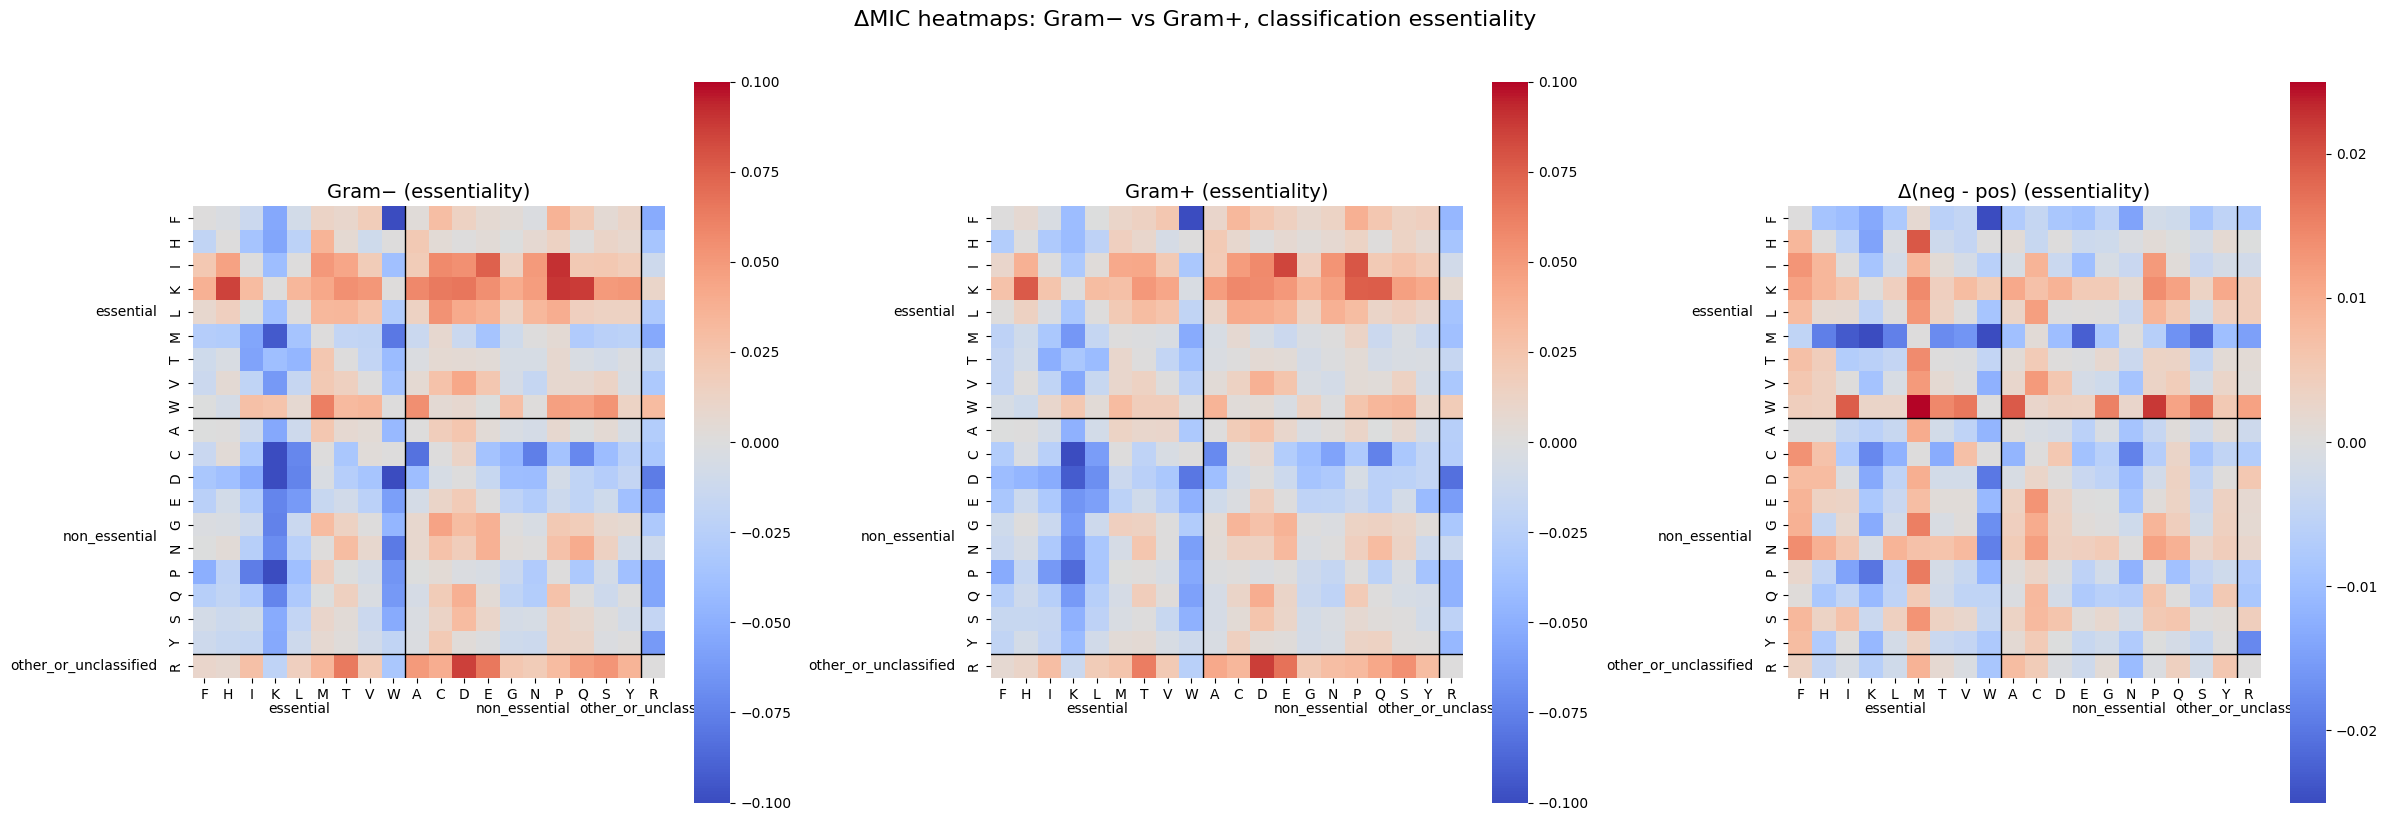

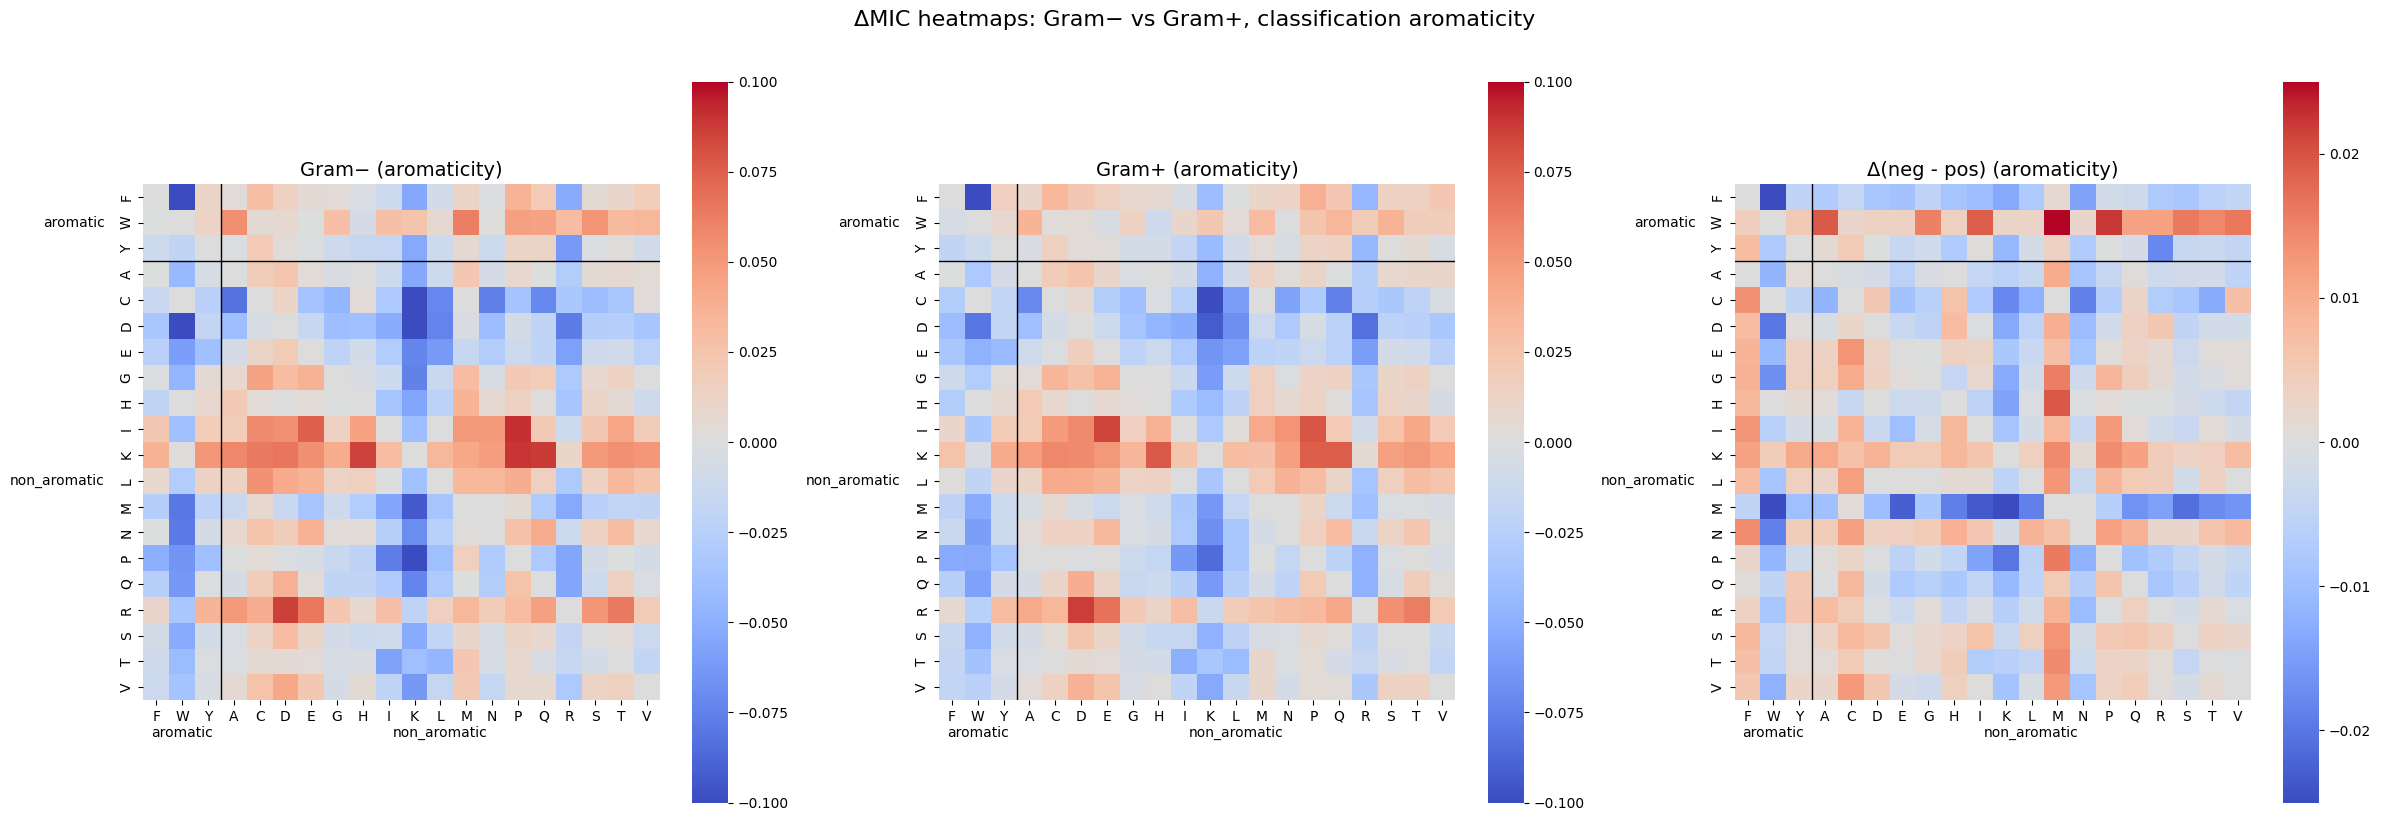

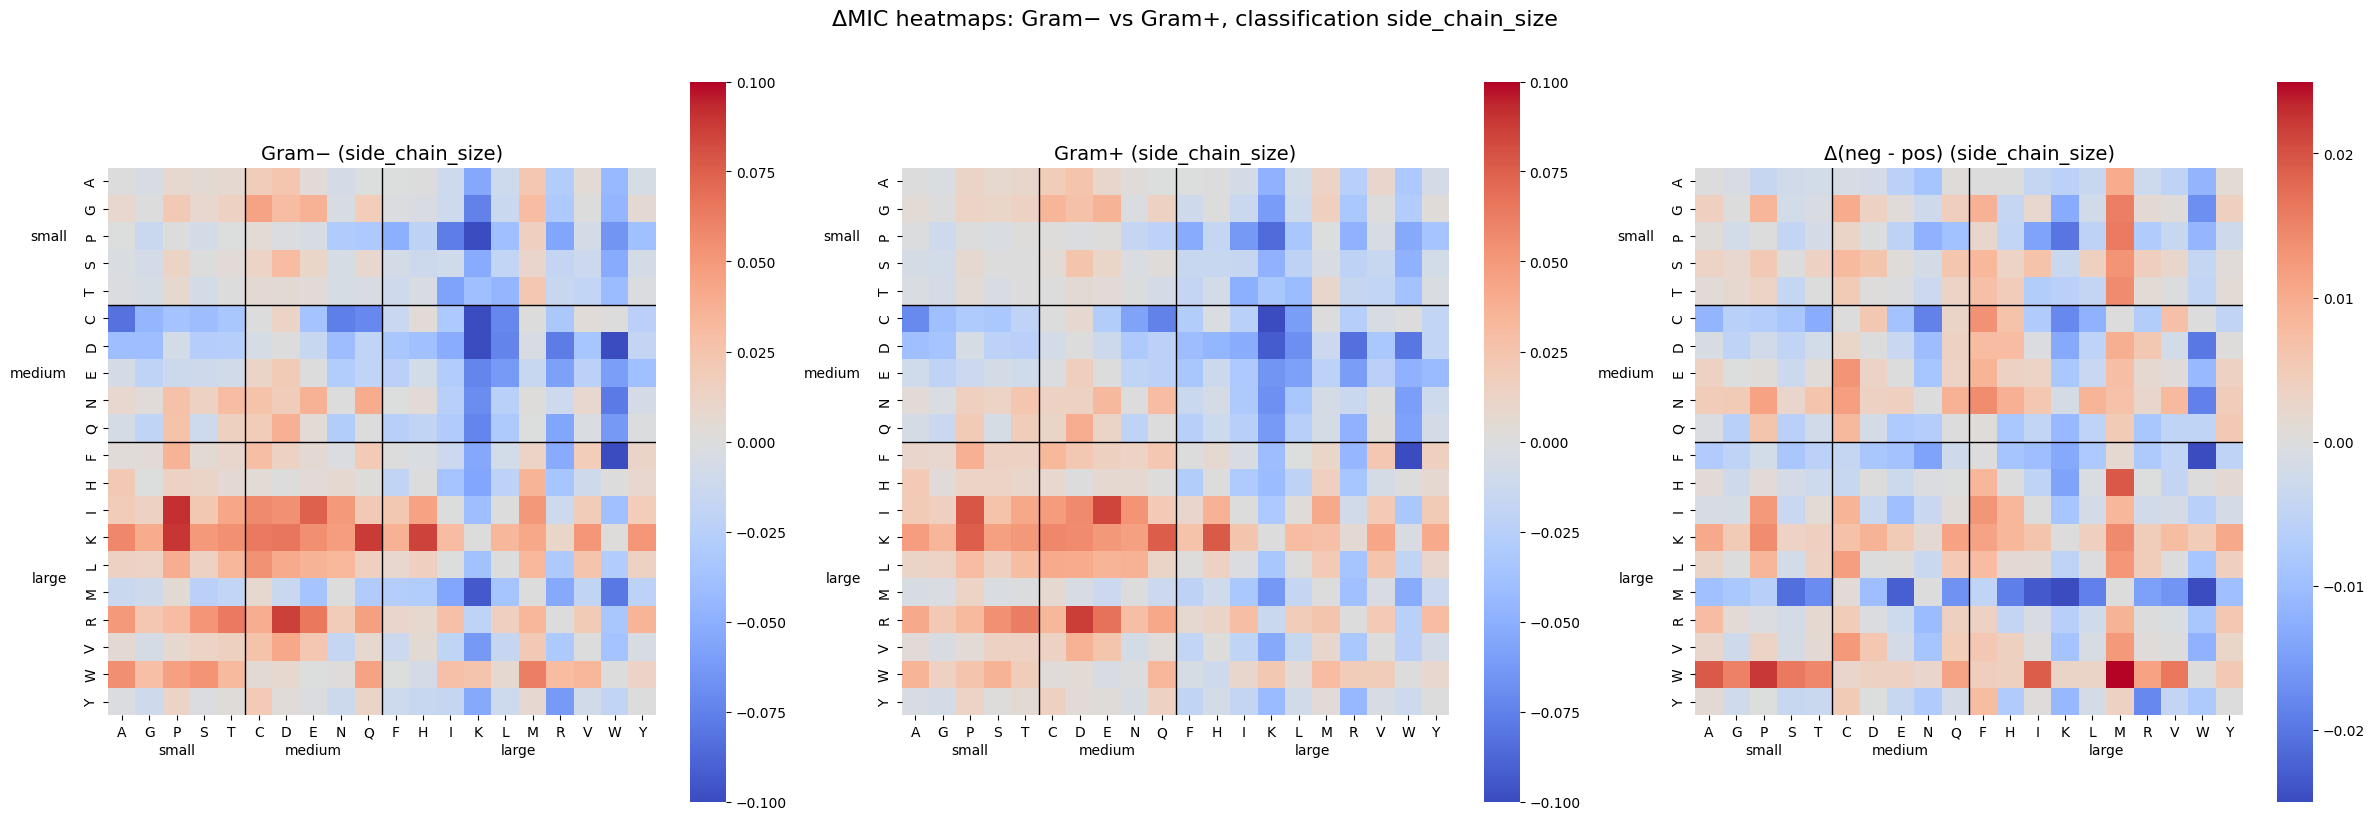

In [22]:
for c in classes:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

    # Draw on given axes instead of creating new ones
    create_square_plot(
        mean_gram_neg_matrix.astype(float),
        classification=c,
        title=f"Gram− ({c})",
        ax=ax1,
        show_labels=True,
        return_fig=False,
        vmin =-0.1,
        vmax=0.1,
    )

    create_square_plot(
        mean_gram_pos_matrix.astype(float),
        classification=c,
        title=f"Gram+ ({c})",
        ax=ax2,
        show_labels=True,
        return_fig=False,
        vmin =-0.1,
        vmax=0.1,
    )

    difference_matrix = mean_gram_neg_matrix - mean_gram_pos_matrix

    create_square_plot(
        difference_matrix.astype(float),
        classification=c,
        title=f"Δ(neg - pos) ({c})",
        ax=ax3,
        show_labels=True,
        return_fig=False,
        vmin=-0.025,
        vmax=0.025,
    )

    fig.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


NOWY ZESTAW

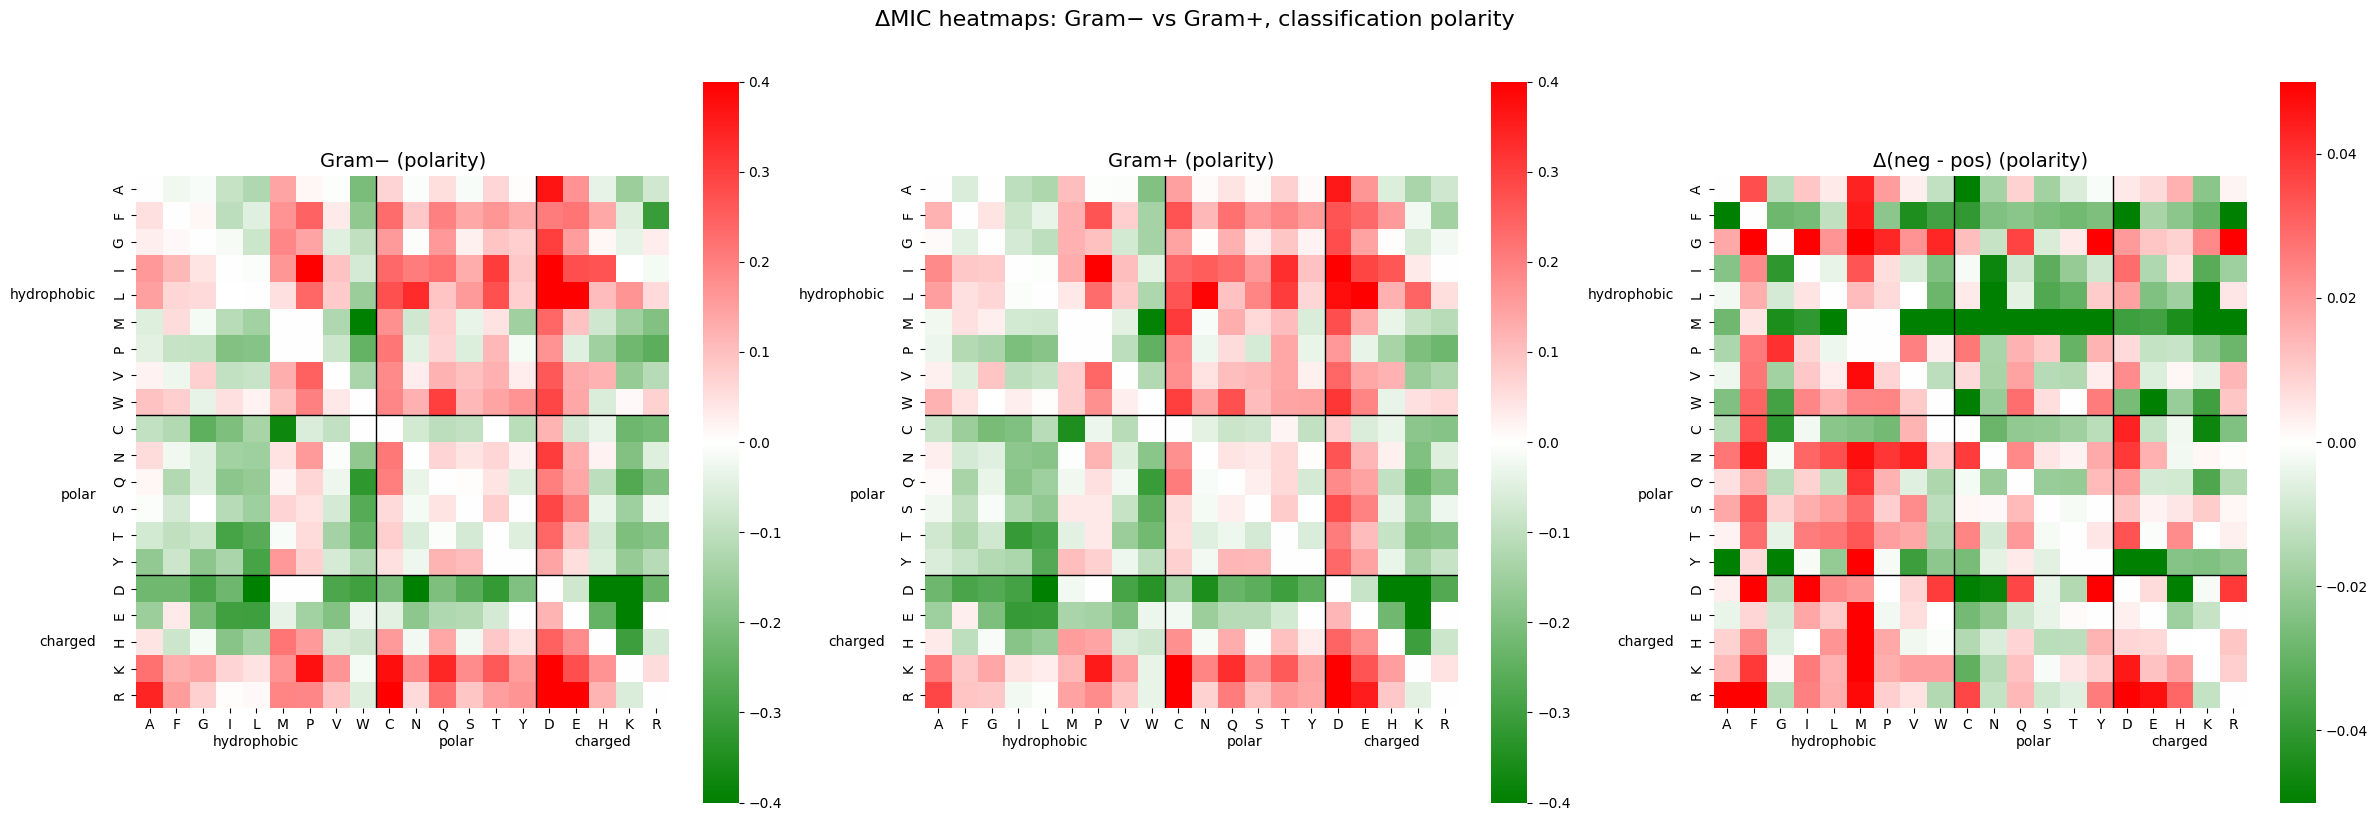

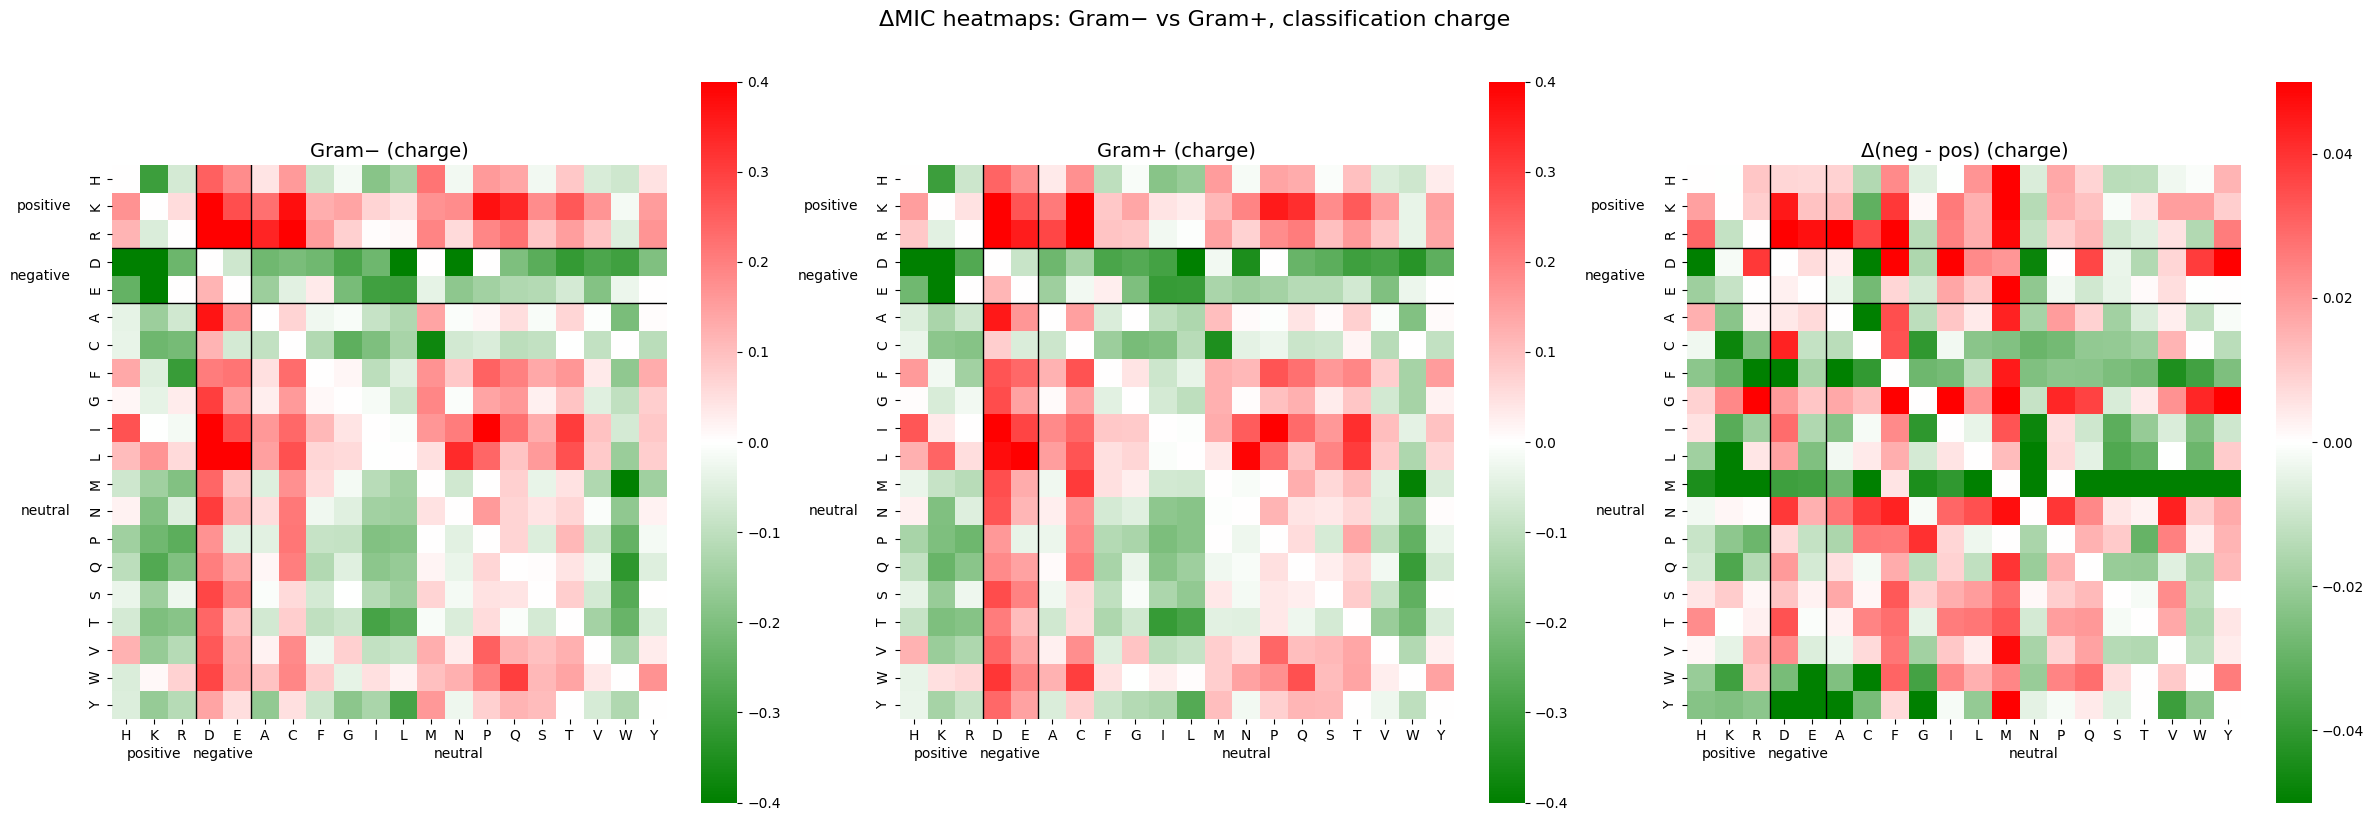

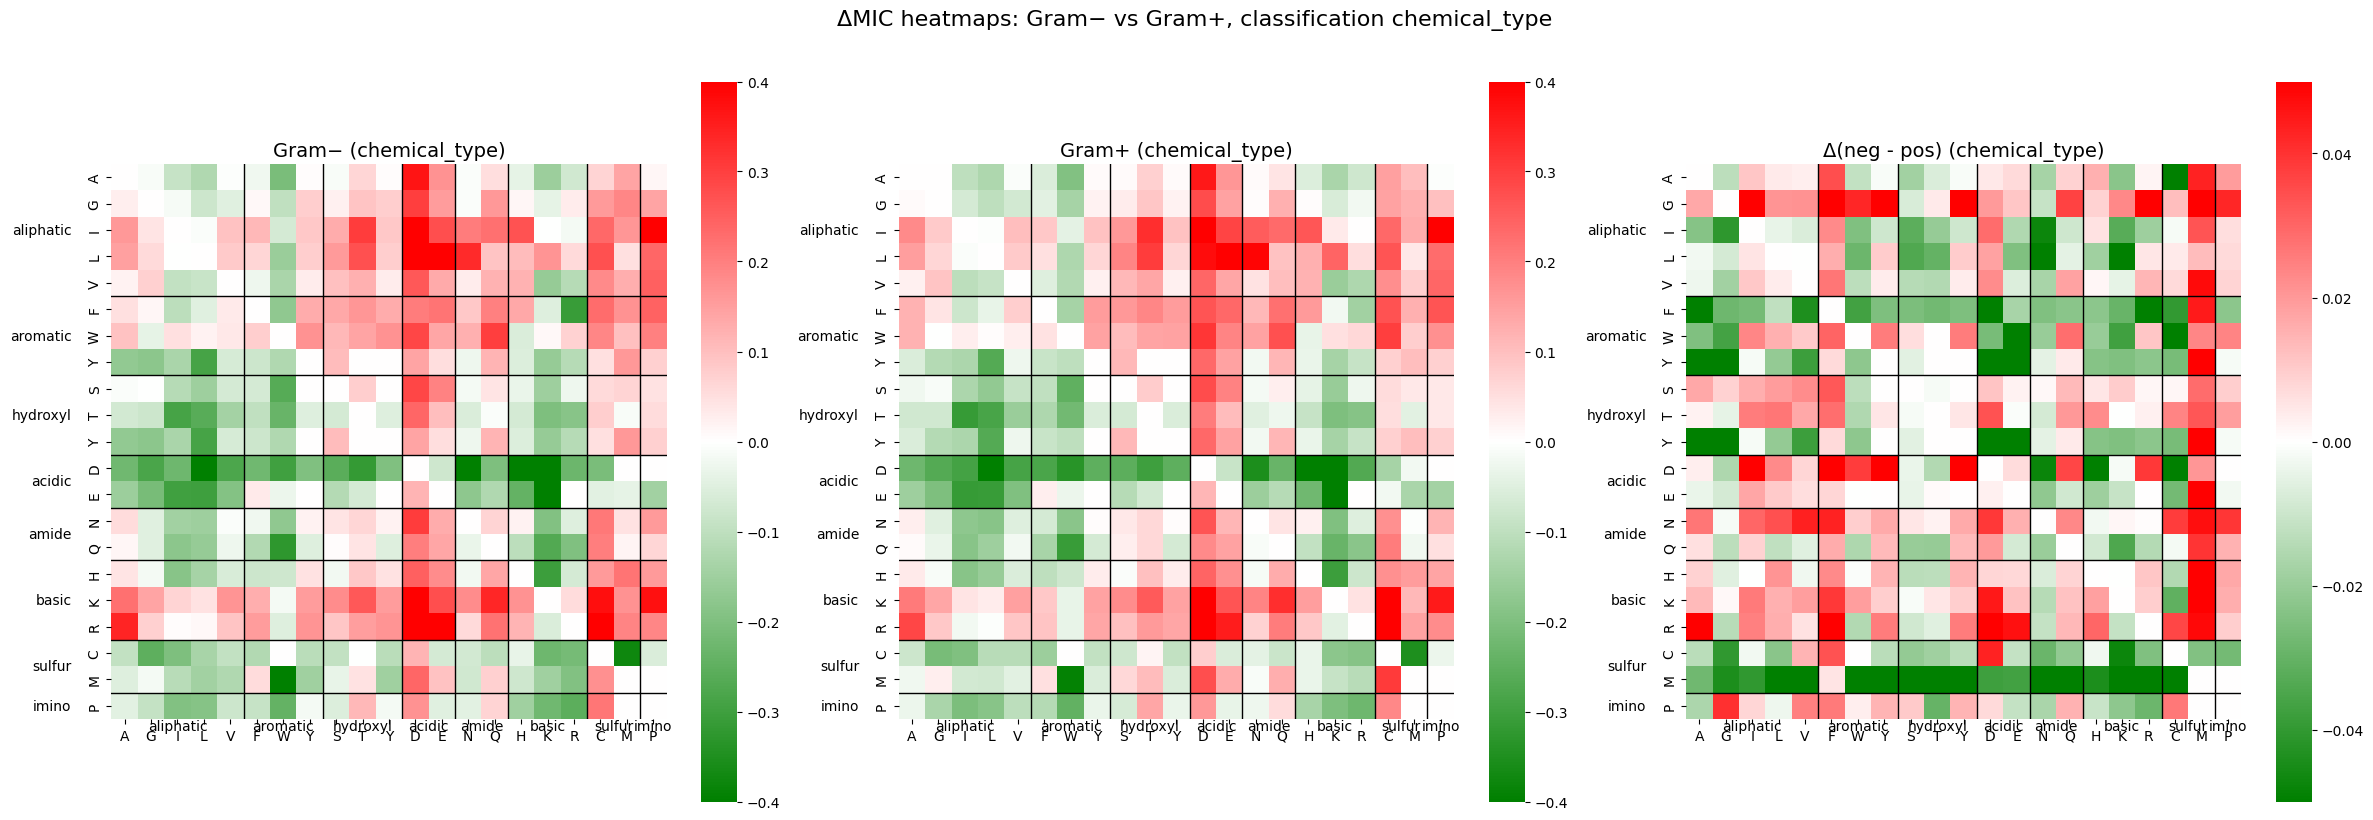

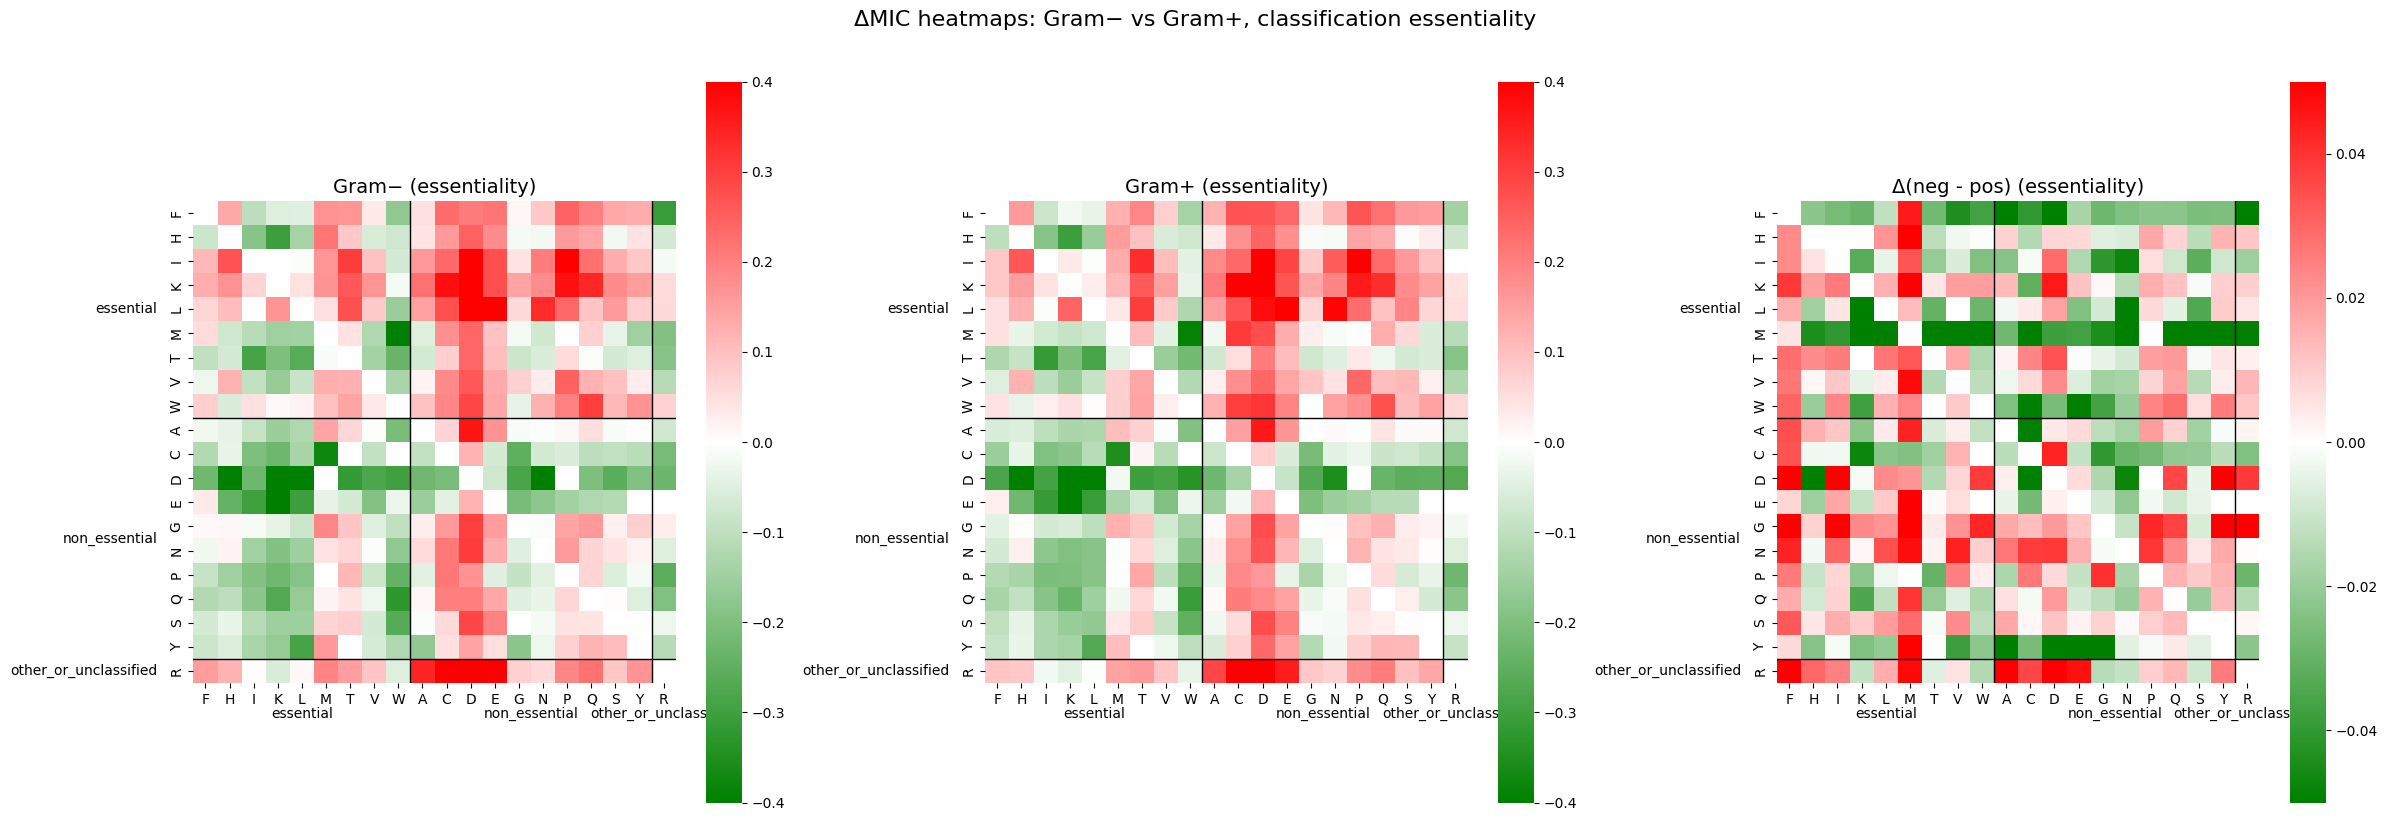

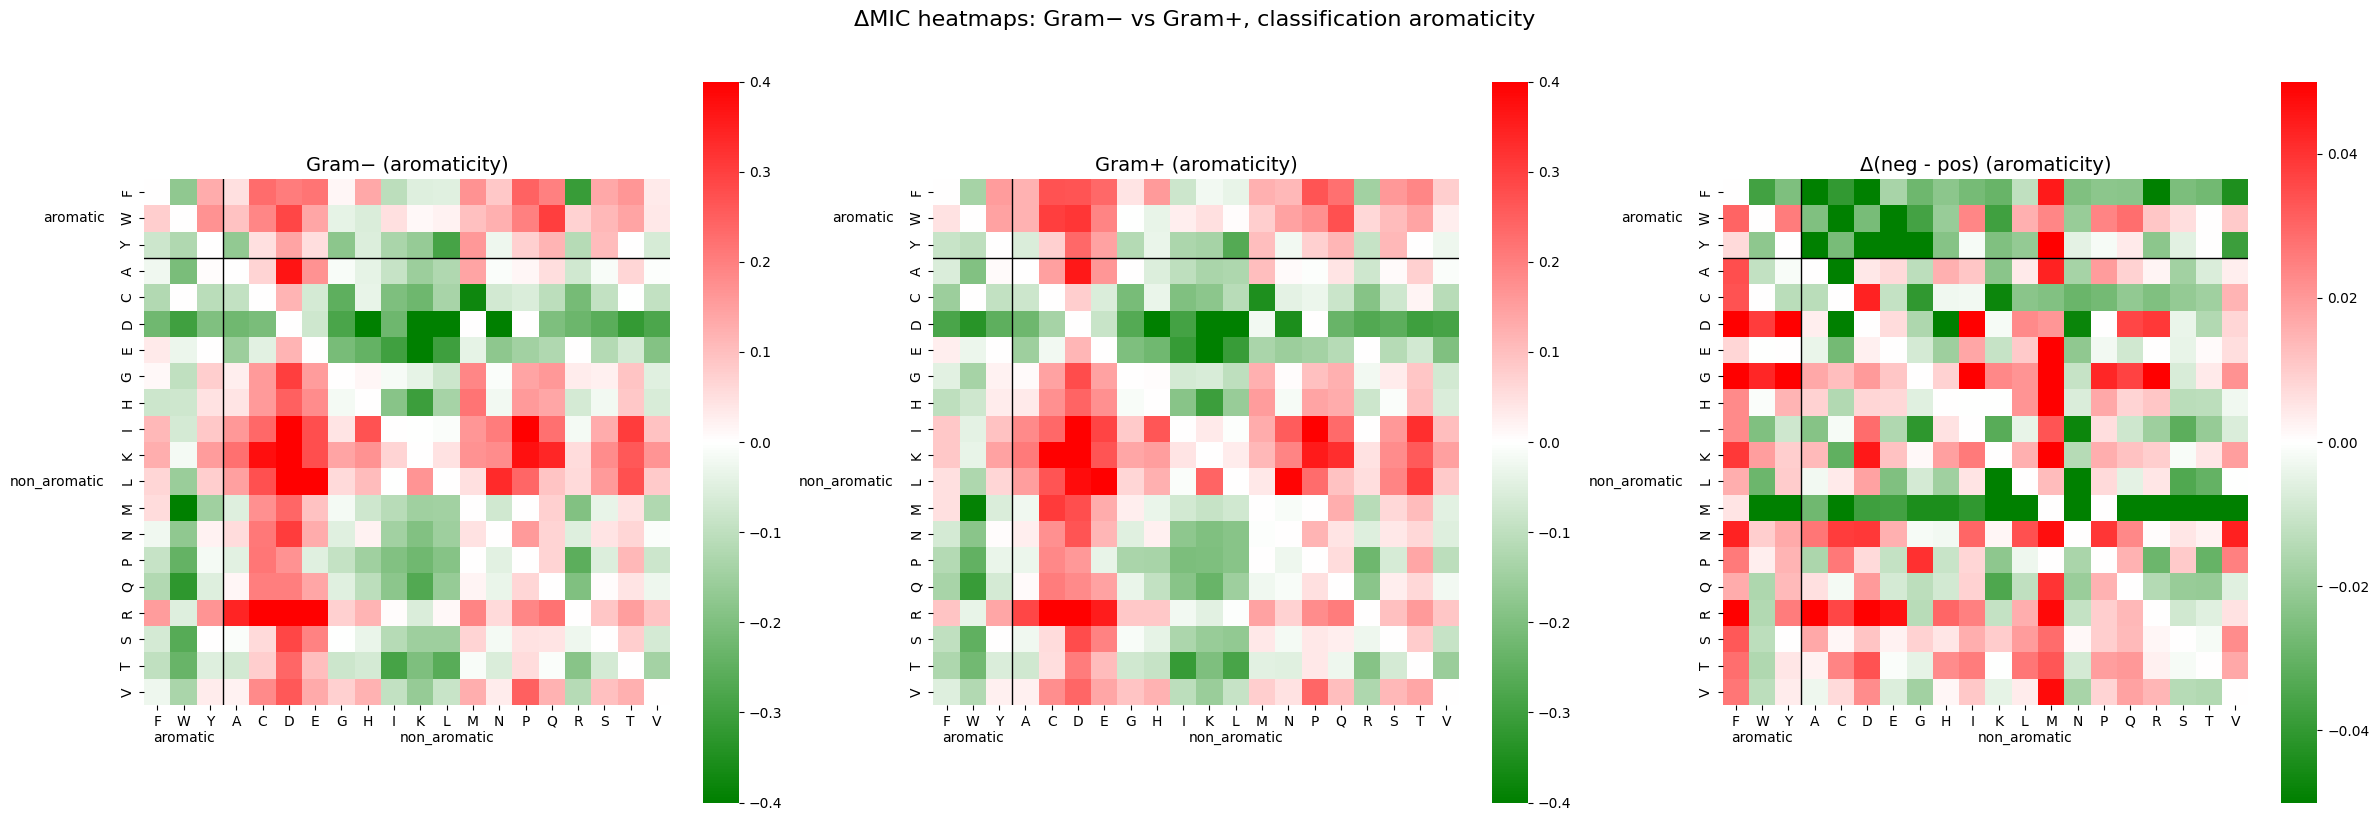

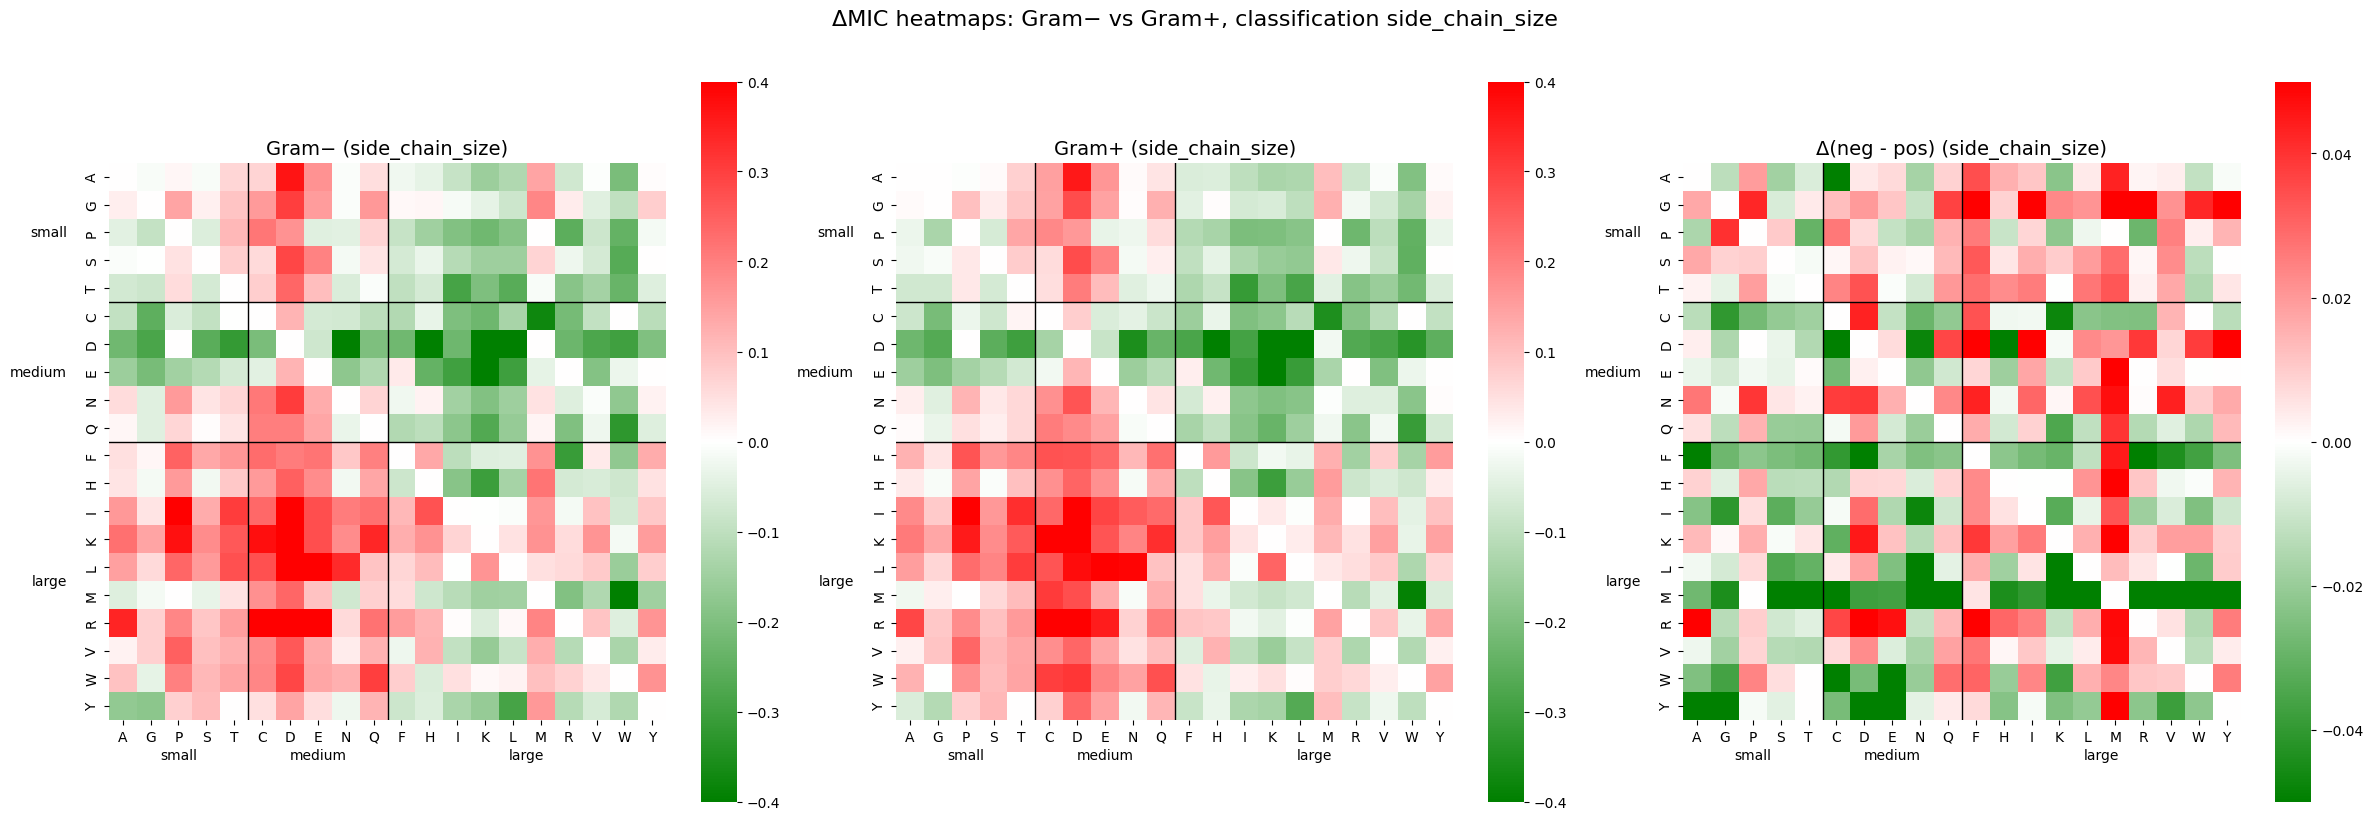

In [22]:
colors = [(0, "green"), (0.5, "white"), (1, "red")]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("greenwarm", colors)


for c in classes:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

    # Draw on given axes instead of creating new ones
    create_square_plot(
        mean_gram_neg_matrix.astype(float),
        classification=c,
        title=f"Gram− ({c})",
        ax=ax1,
        show_labels=True,
        return_fig=False,
        vmin = -0.4,
        vmax = 0.4,
        cmap=custom_cmap

    )

    create_square_plot(
        mean_gram_pos_matrix.astype(float),
        classification=c,
        title=f"Gram+ ({c})",
        ax=ax2,
        show_labels=True,
        return_fig=False,
        vmin = -0.4,
        vmax = 0.4,
        cmap=custom_cmap
    )
    
    difference_matrix = mean_gram_neg_matrix - mean_gram_pos_matrix

    create_square_plot(
        difference_matrix.astype(float),
        classification=c,
        title=f"Δ(neg - pos) ({c})",
        ax=ax3,
        show_labels=True,
        return_fig=False,
        vmin=-0.05,
        vmax=0.05,
        cmap=custom_cmap
    )

    fig.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
